<span style="font-size:25px; color:red">Imports</span> <br> System imports made to make everything work correctly

In [1]:
import sys
import importlib
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

sys.path.append("/Users/arthurbenard/Project 1B/src")

import pandas as pd
import numpy as np
import xgboost
import warnings
warnings.filterwarnings("ignore")

In [2]:
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

In [3]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GroupShuffleSplit, learning_curve, GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score
from sklearn.feature_selection import SelectKBest, chi2, f_classif
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


In [4]:
# Force Jupyter to reload the module from the hard drive
import data_converter.hplc_data_handler

In [5]:
# Now do the specific imports
from data_converter.hplc_data_handler import cleaning_array_by_cas, NMR_SOLVENTS, smiles_to_fingerprint, scrub, compress_fingerprints_pca, calculate_descriptors, extract_solvent_physics
from controller.predictor_runner import generate_ml_ready_file_fingerprint_solvent, generate_ml_ready_file_onehot_solvent, generate_ml_file_with_logs, solubility_file_matrix, add_logs_to_df, add_matrix_id_to_df, run_descriptor_competition, run_hyperparameter_competition
from analysis.analysis import run_ablation_study, plot_comparison, run_data_fraction, plot_learning_curve, run_ablation_xgboost, learning_curve_trainsize_kselectors, run_matrix_ablation

<span style="font-size:25px;color:red">Random Forest</span> <br> The first model tested is RandomForest. The first steps were to succesfully generate a df that would be fed to the model.

**<u><span style="font-size:18px">Getting the file ready</span><u>**

sklearn only speaks "math", therefore SMILES needs to be translated (Morgan Fingerprint that acts as barcode)
created smiles_to_fingerprints in hplc_data_handler

we'll first clean the smiles file + raw data, removing duplicates and 0 signals

In [2]:
csv_file = '/Users/arthurbenard/Project 1B/data/Fichier final (RT+sol)_with_smiles.csv'
df_csv = pd.read_csv(csv_file)


excel_file = '/Users/arthurbenard/Project 1B/data/Fichier final (RT+sol)_with_smiles.xlsx'
df_csv.to_excel(excel_file, index=False)

cleaned_df=cleaning_array_by_cas('/Users/arthurbenard/Project 1B/data/Fichier final (RT+sol)_with_smiles.xlsx', cas_column_name='CAS ')

Original Row Count: 1057
Unique Molecules (by CAS): 144
Redundant Rows Deleted: 906
No Signal Rows Deleted: 913
----------------------------------



solvents also need to be converted to numbers, we'll just get the SMILES and then call the same function smiles_to_fingerprint. the df generated below is only for one solvent given, that way its size is approximately 4 x ~150

This cell is for *MeOH*.

In [ ]:
ml_df = generate_ml_ready_file_fingerprint_solvent(cleaned_df, 'MeOH', NMR_SOLVENTS, smiles_to_fingerprint)

This cell is for *ACN*.

In [ ]:
ml_df = generate_ml_ready_file_fingerprint_solvent(cleaned_df, 'ACN', NMR_SOLVENTS, smiles_to_fingerprint)

**<u><span style="font-size:18px">Writing RandomForest</span><u>**

Let's write a simple model, the **baseline model**. RandomForest is recommended for its ability to handle high dimensions perfectly (our fingerprints generated a lot of 'bits', more rows than columns), handle non-linear data. it is also apparently less prone to overfitting. a good combination of high accuracy, resistance to overfitting, and the ability to easily explain your results. plus we don't have a lot of data... i think it's good to start with this, even though i've read that it isn't very efficient when it comes to predict outside of "what it's seen"

Machine learning models hate hidden arrays. They want one massive, flat 2D grid (like a giant Excel sheet) where every single bit gets its own dedicated column. This means our df content needs to be flattened. *np.vstack* takes those individual arrays out of the Pandas cells and stacks them vertically on top of each other.

In [6]:
X_solute = np.vstack(ml_df['Sample Fingerprint'].values)  
X_solvent = np.vstack(ml_df['Solvent'].values)

# reshaping is necessary, because X_solute is a 2D grid, and when we'll need to glue it back to 'RT' there's going to be a conflict of dimensions (1D vs 2D). 
# so .reshape turns 'RT' in a column of 2D
X_rt = ml_df['RT'].values.reshape(-1, 1)

# glue back together, assign X and y
X = np.hstack((X_solute, X_rt, X_solvent))
y = ml_df['Soluble'].values

print(f"Final X matrix shape: {X.shape}")
print(f"Final y vector shape: {y.shape}")

Final X matrix shape: (144, 4097)
Final y vector shape: (144,)


This is the splitting data set: 70% for training, 20% for validation and 10% for testing

In [ ]:
# Cuts off 30% of the data
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)

# Split that 30% into what is needed
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=(1/3), random_state=42)

print("\n--- Split Complete ---")
print(f"Training Set:   {X_train.shape[0]} rows (70%)")
print(f"Validation Set: {X_val.shape[0]} rows (20%)")
print(f"Testing Set:    {X_test.shape[0]} rows (10%)")


--- Split Complete ---
Training Set:   100 rows (70%)
Validation Set: 29 rows (20%)
Testing Set:    15 rows (10%)


This is the training cell for **Baseline Model**

In [ ]:
# training the Baseline Random Forest ONLY on the training Set
print("Training the Baseline Model ...")
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=75, n_jobs=-1, class_weight='balanced')
rf_baseline.fit(X_train, y_train)

Training the Baseline Model ...


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Validation step for **Baseline Model**, printing out results too

In [15]:
predictions_val = rf_baseline.predict(X_val)

print("\n==============================================")
print("  BASELINE MODEL EXAM RESULTS (VALIDATION SET)")
print("==============================================")
print(classification_report(y_val, predictions_val)) #this will give an idea of the accuracy


  BASELINE MODEL EXAM RESULTS (VALIDATION SET)
              precision    recall  f1-score   support

           0       0.30      0.33      0.32         9
           1       0.68      0.65      0.67        20

    accuracy                           0.55        29
   macro avg       0.49      0.49      0.49        29
weighted avg       0.56      0.55      0.56        29



Confusion Matrix: the Top-Left box is how many insoluble molecules it successfully caught, the Bottom-Right box is how many soluble molecules it successfully identified.

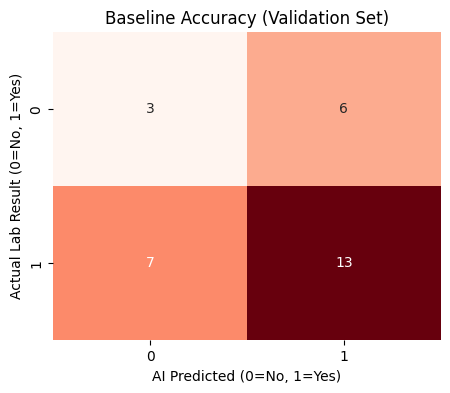

In [16]:
# plotting Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_val, predictions_val), annot=True, fmt='d', cmap='Reds', cbar=False)
plt.title('Baseline Accuracy (Validation Set)')
plt.xlabel('AI Predicted (0=No, 1=Yes)')
plt.ylabel('Actual Lab Result (0=No, 1=Yes)')
plt.show()

Now this is only using one of the solvents available in the dictionary, this will be an attempt at introducing the model to new solvents.

In [2]:
cleaned_df=cleaning_array_by_cas('/Users/arthurbenard/Project 1B/data/Fichier final (RT+sol)_with_smiles.xlsx', cas_column_name='CAS ')

Original Row Count: 1057
Unique Molecules (by CAS): 144
Redundant Rows Deleted: 906
No Signal Rows Deleted: 913
----------------------------------


This cell is different, to uncover if the Morgan fingerprint actually hinders the accuracy the solvents will be coded differently: ***one-hot coded*** to be precise. It just means that for 5 solvents we'll make 5 independent codes. We suspect that somes solvents have too similar fingerprints....

In [ ]:
print("Gathering data for all solvents...")
all_dfs = []
solvents_list = list(NMR_SOLVENTS.keys())

# looping on all solvents
for sol in solvents_list:
    if sol in cleaned_df.columns:
        df_temp = generate_ml_ready_file_onehot_solvent(cleaned_df, sol, NMR_SOLVENTS, smiles_to_fingerprint)
        all_dfs.append(df_temp)
        print(f" - {sol}: added {len(df_temp)} experiments.")


# .concat function that takes a list of separate DataFrames and smashes them on top of each other into one giant DataFrame
mega_df = pd.concat(all_dfs, ignore_index=True)
print(f"MEGA DATAFRAME CREATED: {len(mega_df)} TOTAL ROWS\n")

In [15]:
X_solute = np.vstack(mega_df['Sample Fingerprint'].values)  
X_rt = mega_df['RT'].values.reshape(-1, 1)           
X_solvent = np.vstack(mega_df['Solvent'].values)     

X = np.hstack((X_solute, X_rt, X_solvent))
y = mega_df['Soluble'].values
groups = mega_df['SMILES'].values # Why SMILES? it's to prevent a potential problem, when model will randomly select data as training it might not see that there's mol for MEOH and ACn and DMSO...
                                # this can falsify the precision of the model because it will not differentiate the solvents (it's not learning chemistry). SO by adding SMILES, we tell the code that
                                # if he encounters several similar SMILES to take them all into account in the training, that way in knows there's a difference between solvents.  
                                # generate_ml_ready_filehas been modified for this purpose.

In [16]:
print("Splitting data safely by Molecule...")

# splitting of the data in same proportions as before, GroupShuffleSplit model needed to shuffle as explained before
# first take out the 30% and keep training set
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, temp_idx = next(gss1.split(X, y, groups))

X_train, y_train, groups_temp = X[train_idx], y[train_idx], groups[temp_idx]
X_temp, y_temp = X[temp_idx], y[temp_idx]

# then separate validation and testing
gss2 = GroupShuffleSplit(n_splits=1, test_size=(1/3), random_state=42)
val_idx, test_idx = next(gss2.split(X_temp, y_temp, groups_temp))

X_val, y_val = X_temp[val_idx], y_temp[val_idx]
X_test, y_test = X_temp[test_idx], y_temp[test_idx]

print("\n--- Split Complete ---")
print(f"Training Set:   {X_train.shape[0]} rows (70%)")
print(f"Validation Set: {X_val.shape[0]} rows (20%)")
print(f"Testing Set:    {X_test.shape[0]} rows (10%)")

Splitting data safely by Molecule...

--- Split Complete ---
Training Set:   500 rows (70%)
Validation Set: 145 rows (20%)
Testing Set:    75 rows (10%)


In [17]:
rf_mega = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_mega.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [18]:
y_val_pred = rf_mega.predict(X_val)

print("=========================================")
print("  MEGA MODEL EXAM RESULTS (VALIDATION SET)")
print("=========================================")
print(classification_report(y_val, y_val_pred))

  MEGA MODEL EXAM RESULTS (VALIDATION SET)
              precision    recall  f1-score   support

           0       0.61      0.20      0.31        54
           1       0.66      0.92      0.77        91

    accuracy                           0.66       145
   macro avg       0.64      0.56      0.54       145
weighted avg       0.64      0.66      0.60       145



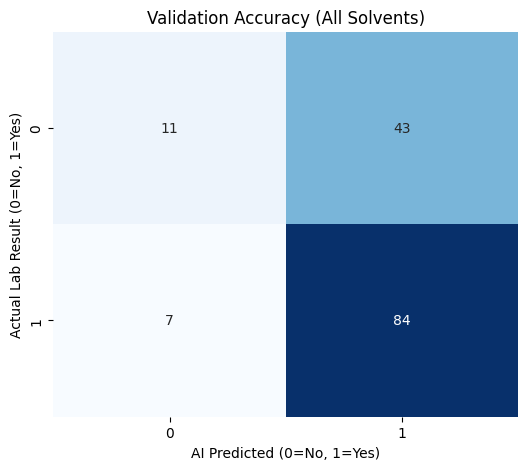

In [19]:
# Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_val, y_val_pred), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Validation Accuracy (All Solvents)')
plt.xlabel('AI Predicted (0=No, 1=Yes)')
plt.ylabel('Actual Lab Result (0=No, 1=Yes)')
plt.show()

A 1% increase in accuracy has been observed, not much but something at least... Let's add a new parameter to train on and analyze the outcome: **predicted logS** from Fastsolv. New function has been made in predictor_runner

First, we need to prepare the cleaned_df, make sure the predicted logS is in it (we've been working without it for a while).

In [2]:
cleaned_df=cleaning_array_by_cas('/Users/arthurbenard/Project 1B/data/Fichier final (RT+sol)_with_smiles.xlsx', cas_column_name='CAS ')
# recalculating solubility
"""sol_matrix = solubility_file_matrix(cleaned_df, NMR_SOLVENTS)"""
sol_matrix= pd.read_excel('/Users/arthurbenard/Project 1B/data/Master_Solubility_Matrix.xlsx')

Original Row Count: 1057
Unique Molecules (by CAS): 144
Redundant Rows Deleted: 906
No Signal Rows Deleted: 913
----------------------------------


In [3]:
final_working_df = add_logs_to_df(cleaned_df, sol_matrix, NMR_SOLVENTS)

Successfully added 5 exact logS columns


In [ ]:
print("Gathering data for all solvents...")
all_dfs_v3 = []

for sol in NMR_SOLVENTS.keys():
    # since we are using cleaned_df, we just look for 'MeOH', 'ACN', etc.
    if sol in cleaned_df.columns:
        df_temp = generate_ml_file_with_logs(final_working_df, sol, NMR_SOLVENTS, smiles_to_fingerprint)
        all_dfs_v3.append(df_temp)
        print(f"Added {sol}: {len(df_temp)} rows")
    else:
        print(f"Skipped {sol}: Column not found")

# sticking everything together
mega_df_v3 = pd.concat(all_dfs_v3, ignore_index=True)
print(f"DataFrame built! Total Rows: {len(mega_df_v3)}")

In [5]:
X_solute = np.vstack(mega_df_v3['Sample Fingerprint'].values)  
X_rt     = mega_df_v3['RT'].values.reshape(-1, 1)    
X_logs   = mega_df_v3['logS'].values.reshape(-1, 1)  # NEW reshaping like above line
X_solvent= np.vstack(mega_df_v3['Solvent'].values)

X_v3 = np.hstack((X_solute, X_rt, X_logs, X_solvent))
y_v3 = mega_df_v3['Soluble'].values
groups_v3 = mega_df_v3['SMILES'].values

print(f" Final matrix shape: {X_v3.shape}")

 Final matrix shape: (720, 2055)


Now that the final matrix is done, let's train.

In [6]:
print("Splitting data safely by Molecule...")

# splitting of the data in same proportions as before, GroupShuffleSplit model needed to shuffle as explained before
# first take out the 30% and keep training set
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, temp_idx = next(gss1.split(X_v3, y_v3, groups_v3))

X_train, y_train, groups_temp = X_v3[train_idx], y_v3[train_idx], groups_v3[temp_idx]
X_temp, y_temp = X_v3[temp_idx], y_v3[temp_idx]

# then separate validation and testing
gss2 = GroupShuffleSplit(n_splits=1, test_size=(1/3), random_state=42)
val_idx, test_idx = next(gss2.split(X_temp, y_temp, groups_temp))

X_val, y_val = X_temp[val_idx], y_temp[val_idx]
X_test, y_test = X_temp[test_idx], y_temp[test_idx]

print("\n--- Split Complete ---")
print(f"Training Set:   {X_train.shape[0]} rows (70%)")
print(f"Validation Set: {X_val.shape[0]} rows (20%)")
print(f"Testing Set:    {X_test.shape[0]} rows (10%)")

Splitting data safely by Molecule...

--- Split Complete ---
Training Set:   500 rows (70%)
Validation Set: 145 rows (20%)
Testing Set:    75 rows (10%)


In [10]:
rf_mega = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_mega.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [11]:
y_val_pred = rf_mega.predict(X_val)

print("=========================================")
print("  V3 MEGA MODEL EXAM RESULTS (VALIDATION SET)")
print("=========================================")
print(classification_report(y_val, y_val_pred))

  V3 MEGA MODEL EXAM RESULTS (VALIDATION SET)
              precision    recall  f1-score   support

           0       0.80      0.37      0.51        54
           1       0.72      0.95      0.82        91

    accuracy                           0.73       145
   macro avg       0.76      0.66      0.66       145
weighted avg       0.75      0.73      0.70       145



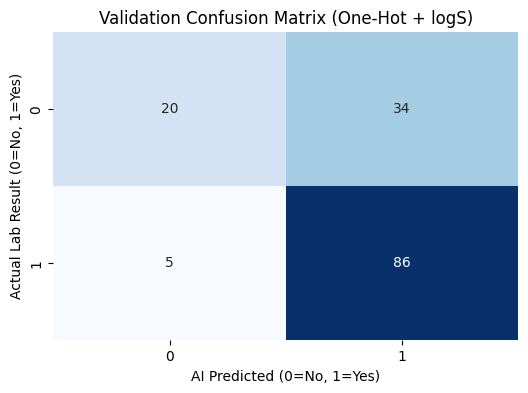

In [12]:
# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_val, y_val_pred), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Validation Confusion Matrix (One-Hot + logS)')
plt.xlabel('AI Predicted (0=No, 1=Yes)')
plt.ylabel('Actual Lab Result (0=No, 1=Yes)')
plt.show()

**<u><span style="font-size:18px">Ablation Studies on RandomForest</span><u>**

This cell right under is part of the 'removing features from model' function I wrote. I'm testing out different things and saving them in files (removing ***A*** feature then removing ***SOME*** features).

In [12]:
df_results = run_ablation_study(mega_df_v3)

  AVAILABLE FEATURES TO REMOVE:
  - Sample Fingerprint
  - RT
  - logS
  - Solvent
  - None (Keep all features)

Removing [Sample Fingerprint] from model...
Matrix shape after removal: (720, 7)
   -> Results saved to /Users/arthurbenard/Project 1B/src/analysis/model_analysis_results/ablation_results_no_Sample_Fingerprint.txt




Removing [None] from model...
Matrix shape after removal: (720, 2055)
   -> Results saved to /Users/arthurbenard/Project 1B/src/analysis/model_analysis_results/ablation_results_no_None.txt


Removing [RT] from model...
Matrix shape after removal: (720, 2054)
   -> Results saved to /Users/arthurbenard/Project 1B/src/analysis/model_analysis_results/ablation_results_no_RT.txt


Removing [logS] from model...
Matrix shape after removal: (720, 2054)
   -> Results saved to /Users/arthurbenard/Project 1B/src/analysis/model_analysis_results/ablation_results_no_logS.txt


Removing [RT, logS] from model...
Matrix shape after removal: (720, 2055)
   -> Results saved to /Users/arthurbenard/Project 1B/src/analysis/model_analysis_results/ablation_results_no_RT,_logS.txt


Removing [Sample Fingerprint] from model...
Matrix shape after removal: (720, 7)
   -> Results saved to /Users/arthurbenard/Project 1B/src/analysis/model_analysis_results/ablation_results_no_Sample_Fingerprint.txt


Removing [Sampl

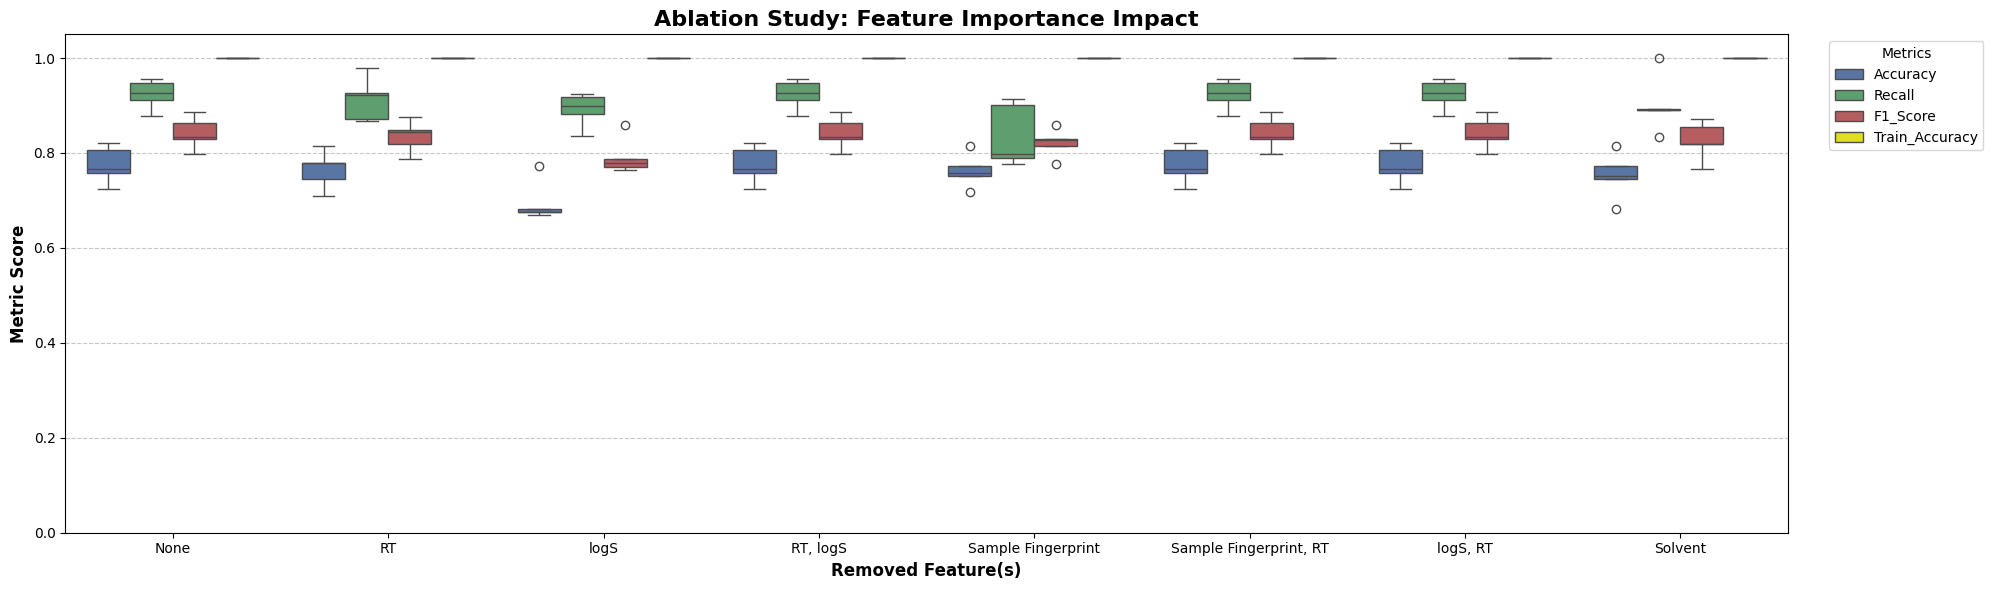

In [5]:
df_none = run_ablation_study(mega_df_v3, features_to_remove='None')
df_rt = run_ablation_study(mega_df_v3, features_to_remove='RT')
df_logs = run_ablation_study(mega_df_v3, features_to_remove='logS')
df_both = run_ablation_study(mega_df_v3, features_to_remove='RT, logS')
df_fp = run_ablation_study(mega_df_v3, features_to_remove='Sample Fingerprint')
df_fp_rt = run_ablation_study(mega_df_v3, features_to_remove='Sample Fingerprint, RT')
df_fp_logs = run_ablation_study(mega_df_v3, features_to_remove='logS, RT')
df_sol = run_ablation_study(mega_df_v3, features_to_remove='Solvent')

# Glue them together into one massive DataFrame
all_results_df = pd.concat([df_none, df_rt, df_logs, df_both, df_fp, df_fp_rt, df_fp_logs, df_sol], ignore_index=True)

plot_comparison(all_results_df)

**<u><span style="font-size:18px">Training data size study</span><u>**

Leander recommended we try to plot a "learning curve" of the model. This means starting with a small sample to train on and increasing until we reach 70%. I'm going to write a function that has a loop which modifies which section of the data to take in, and returns a .txt file. Then we'll worry about the plot.

Let's try with 10% of training

In [5]:
run_data_fraction(mega_df_v3, 0.1 )


Running Learning Curve Step: 10% of total data...
   -> Results saved to /Users/arthurbenard/Project 1B/src/analysis/learning_curve_results/dynamic_learning_curve_10pct.txt


,Train_Size_Pct,Seed,Train_Accuracy,Val_Accuracy,Test_Accuracy,Precision,Recall,F1_Score
0,10,42,1.0,0.634884,0.663636,0.800000,0.613139,0.694215
1,10,93,1.0,0.637209,0.713636,0.740331,0.893333,0.809668
2,10,123,1.0,0.688372,0.672727,0.666667,0.978723,0.793103
3,10,2024,1.0,0.676744,0.700000,0.697115,0.979730,0.814607
4,10,777,1.0,0.737209,0.645455,0.773109,0.643357,0.702290


Let's loop this now to increase the set all the way to 70%

In [ ]:
percentages_to_test = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70]
all_learning_curve_results = []

for pct in percentages_to_test:
    # Call the function we just built
    df_step = run_data_fraction(mega_df_v3, train_percent_of_total=pct)
    
    # Add the results to our list
    all_learning_curve_results.append(df_step)

# Glue everything together into one master DataFrame for plotting later
master_lc_df = pd.concat(all_learning_curve_results, ignore_index=True)

print("\nAll learning curve steps complete and concatenated")

Generating Learning Curve Plot...
-> Plot successfully saved to /Users/arthurbenard/Project 1B/src/analysis/learning_curve_results/Learning_Curve_Plot.png


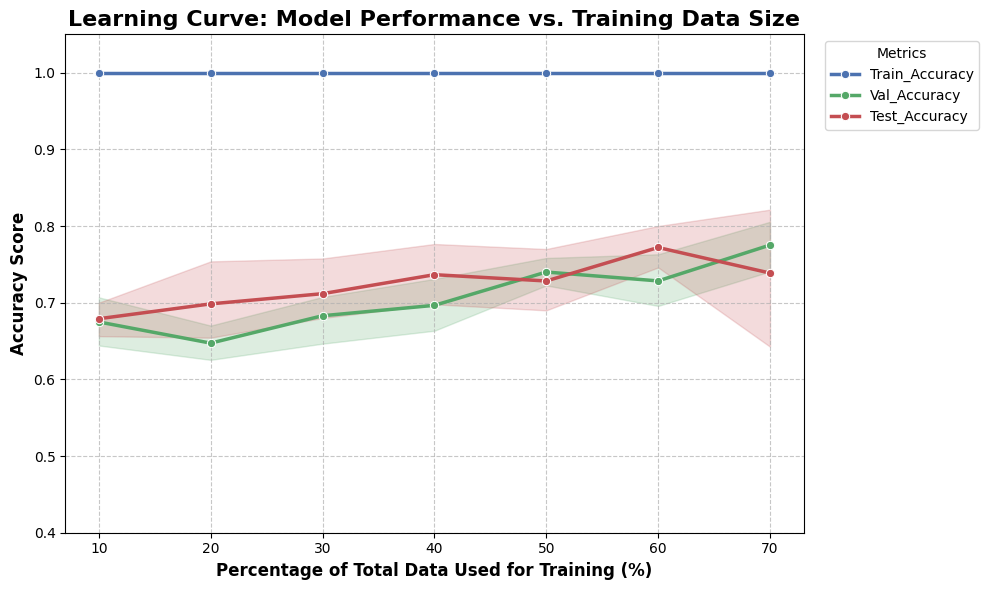

In [6]:
plot_learning_curve(master_lc_df)

**<u><span style="font-size:18px">Adding more Descriptors</span><u>**

Now that RT and logS have successfully been added to the training model, let's see if adding another parameter helps predict better: the **matrix ID**. Since there's only 7 different types of matrix IDs, I recommend using one-hot coding again. We can't use our current cleaning_array functions because this time we need the repeating data (they only differ by Matrix ID).

In [7]:
raw_df = pd.read_excel('/Users/arthurbenard/Project 1B/data/Fichier final (RT+sol)_with_smiles.xlsx')
print(raw_df['Matrix ID Name'].value_counts())


Matrix ID Name
matrix ID BlueBird 1    151
matrix ID PFP 1         151
matrix ID PolarTec 1    151
matrix ID RP18 1        151
matrix ID RP18 2        151
matrix ID Sphinx 1      151
matrix ID Sphinx 2      151
Name: count, dtype: int64


In [8]:
clean_df = scrub(raw_df, smiles_col='solute_smiles')
"""sol_matrix = solubility_file_matrix(clean_df, NMR_SOLVENTS)"""
sol_matrix= pd.read_excel('/Users/arthurbenard/Project 1B/data/Master_Solubility_Matrix.xlsx')

🧹 Starting cleanup. Original rows: 1057


[14:06:00] SMILES Parse Error: syntax error while parsing: Did
[14:06:00] SMILES Parse Error: check for mistakes around position 1:
[14:06:00] Did
[14:06:00] ^
[14:06:00] SMILES Parse Error: Failed parsing SMILES 'Did' for input: 'Did'


   -> Dropped 1 rows containing invalid or missing SMILES.
✅ Cleaned row count: 1056


In [ ]:
final_working_df = add_logs_to_df(clean_df, sol_matrix, NMR_SOLVENTS)

In [ ]:
print("Gathering data for all solvents...")
all_dfs_v3 = []

for sol in NMR_SOLVENTS.keys():
    # since we are using cleaned_df, we just look for 'MeOH', 'ACN', etc.
    if sol in clean_df.columns:
        df_temp = generate_ml_file_with_logs(final_working_df, sol, NMR_SOLVENTS, smiles_to_fingerprint)
        all_dfs_v3.append(df_temp)
        print(f"Added {sol}: {len(df_temp)} rows")
    else:
        print(f"Skipped {sol}: Column not found")

# sticking everything together
mega_df_v3 = pd.concat(all_dfs_v3, ignore_index=True)
print(f"DataFrame built! Total Rows: {len(mega_df_v3)}")

In [12]:
mega_df_v3 = mega_df_v3.rename(columns={'SMILES': 'solute_smiles', 'SMILES ': 'solute_smiles'})
mega_df_v4 = add_matrix_id_to_df(mega_df_v3, raw_df, 'Matrix ID Name')

One-Hot Encoding the 'Matrix ID Name' column...
   Successfully packed 7 matrices: ['matrix ID BlueBird 1' 'matrix ID PFP 1' 'matrix ID PolarTec 1'
 'matrix ID RP18 1' 'matrix ID RP18 2' 'matrix ID Sphinx 1'
 'matrix ID Sphinx 2']
   -> Example array looks like: [1 0 0 0 0 0 0]


Okay now that we know for sure that the matrix ID is included, lets train the model.

In [13]:
mega_df_v4 = mega_df_v4.rename(columns={'solute_smiles': 'SMILES'})

In [12]:
mega_df_v5 = compress_fingerprints_pca(mega_df_v4, fp_col_name='Sample Fingerprint', variance_to_keep=0.95)

Compressing 'Sample Fingerprint' using PCA...
-> Target: Keep 95.0% of the original chemical information.
   Compression Complete!
   -> Original Dimensions: 2048 bits
   -> New Dimensions:      114 dense features


**<u><span style="font-size:18px">Training data size study with more descriptors</span><u>**

In [ ]:
percentages_to_test = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70]
all_learning_curve_results = []

for pct in percentages_to_test:
    # Call the function we just built
    df_step = run_data_fraction(mega_df_v5, train_percent_of_total=pct)
    
    # Add the results to our list
    all_learning_curve_results.append(df_step)

# Glue everything together into one master DataFrame for plotting later
master_lc_df = pd.concat(all_learning_curve_results, ignore_index=True)

print("\nAll learning curve steps complete and concatenated")

Generating Learning Curve Plot...
-> Plot successfully saved to /Users/arthurbenard/Project 1B/src/analysis/learning_curve_results/Learning_Curve_Plot.png


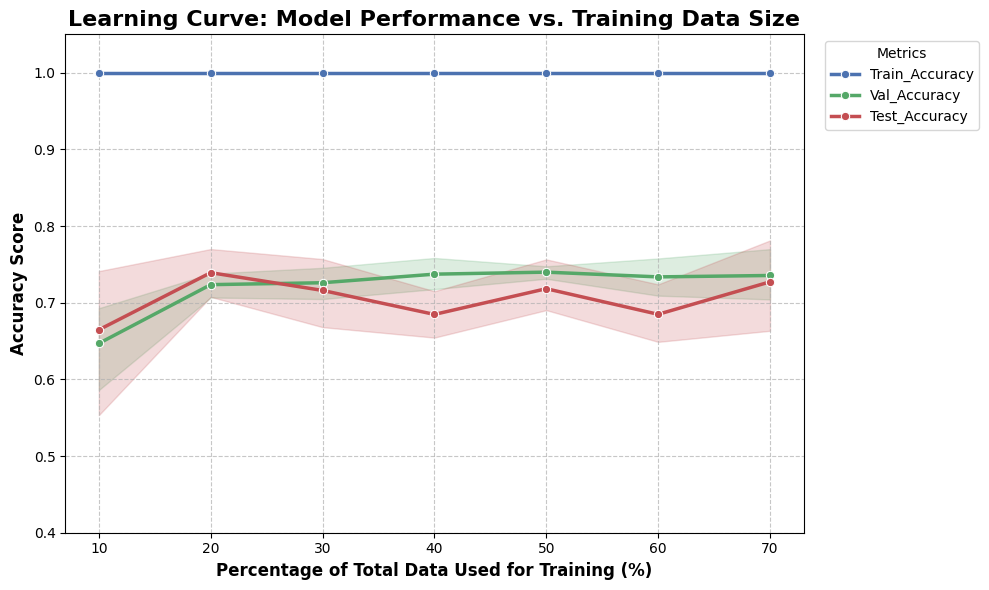

In [18]:
plot_learning_curve(master_lc_df)

It has been suggested that the Ai is "lazy" and attributes 'Soluble' status blindly, primarly because the set list is imbalanced. This has to be checked, and if so it may be possible to fix it with class_weight='balanced'. Let's see.

In [13]:
raw_col_name = 'Sample Fingerprint' 

print(f"Extracting raw 2048-bit fingerprints from '{raw_col_name}'...")

# Stack all the tiny arrays into one giant 2D matrix (just like for PCA)
X_raw = np.vstack(mega_df_v4[raw_col_name].values)
y = mega_df_v4['Soluble'].values.astype(int)

# Split it into Train and Test sets
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, 
    y, 
    test_size=0.20, 
    random_state=56
)

Extracting raw 2048-bit fingerprints from 'Sample Fingerprint'...


**<u><span style="font-size:18px">From MorganFingerprint to SKBest, selecting the best descriptors</span><u>**

In [ ]:
k_values_to_test = [50, 100, 200, 500, 1000, 2048] # 2048 represents using ALL bits

# Lists to store our results for the plot
train_accuracies = []
test_accuracies = []

print(" Starting SelectKBest Optimization Loop...\n")

for k in k_values_to_test:
    print(f"Testing k={k} best features...")
    
    # --- A. FEATURE SELECTION ---
    if k == 2048:
        # If 2048, just use the raw data without cutting anything
        X_train_k = X_train_raw
        X_test_k = X_test_raw
    else:
        # chi2 is the perfect statistical test for 0s and 1s
        selector = SelectKBest(score_func=chi2, k=k)
        # fit_transform learns which bits are best from the Train set AND cuts it down
        X_train_k = selector.fit_transform(X_train_raw, y_train)
        # transform just cuts the Test set down using the same rules
        X_test_k = selector.transform(X_test_raw)
    
    # --- B. TRAIN THE MODEL ---
    # We keep class_weight='balanced' to handle your 67/33 imbalance!
    rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    rf.fit(X_train_k, y_train)
    
    # --- C. SCORE THE MODEL ---
    # We want to see how well it does on BOTH sets to check for overfitting
    train_score = accuracy_score(y_train, rf.predict(X_train_k))
    test_score = accuracy_score(y_test, rf.predict(X_test_k))
    
    train_accuracies.append(train_score)
    test_accuracies.append(test_score)


# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(k_values_to_test, train_accuracies, label='Training Accuracy', marker='o', color='blue')
plt.plot(k_values_to_test, test_accuracies, label='Testing Accuracy', marker='s', color='orange')

plt.title("SelectKBest Optimization: Overfitting Check")
plt.xlabel("Number of Fingerprint Bits Kept (k)")
plt.ylabel("Accuracy Score")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**<span style="font-size:25px;color:red">XGBoost</span>**

**<u><span style="font-size:18px">Testing out</span><u>**

I think it's time to switch up models. We're going to test out XGBoost, which builds simple decision trees and stacks them to correct the specific residual errors of the previous ones. It also supposedly faster.

In [13]:
print("Stitching PCA, Solvent, and Matrix features together...")

# Extract the three separate arrays
X_pca = np.vstack(mega_df_v5['Sample Fingerprint'].values)
X_solvent = np.vstack(mega_df_v5['Solvent'].values)
X_matrix = np.vstack(mega_df_v5['Matrix_Packed_Array'].values)

# Glue them side-by-side using hstack (horizontal stack)
X_combined = np.hstack((X_pca, X_solvent, X_matrix))
y = mega_df_v5['Soluble'].values.astype(int)

print(f"New feature shape (molecules + solvent + matrix): {X_combined.shape}")

# Split the new fully-loaded dataset
print("Splitting data...")
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, 
    y, 
    test_size=0.20, 
    random_state=56
)

Stitching PCA, Solvent, and Matrix features together...
New feature shape (molecules + solvent + matrix): (36930, 126)
Splitting data...


In [23]:
print("Initializing XGBoost model...")
xgb_model = xgboost.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

print("Training the model on PCA features...")
xgb_model.fit(X_train, y_train)

print("Testing the model...")
y_pred = xgb_model.predict(X_test)

Initializing XGBoost model...
Training the model on PCA features...
Testing the model...


In [24]:
accuracy = accuracy_score(y_test, y_pred)
print(f"\n--- RESULTS ---")
print(f"Overall Accuracy: {accuracy * 100:.2f}%\n")
print("Detailed Breakdown:")
print(classification_report(y_test, y_pred))


--- RESULTS ---
Overall Accuracy: 98.81%

Detailed Breakdown:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      2440
           1       0.99      0.99      0.99      4946

    accuracy                           0.99      7386
   macro avg       0.99      0.99      0.99      7386
weighted avg       0.99      0.99      0.99      7386



In [25]:
# Calculate the matrix using your test data and predictions
cm = confusion_matrix(y_test, y_pred)

# Break down the grid into the four categories
true_negatives = cm[0, 0]
false_positives = cm[0, 1]
false_negatives = cm[1, 0]
true_positives = cm[1, 1]

print("--- CONFUSION MATRIX (RAW NUMBERS) ---")
print(f"Correctly predicted Insoluble (True Negatives): {true_negatives}")
print(f"Correctly predicted Soluble (True Positives):   {true_positives}")
print("-" * 45)
print(f"MISTAKE - Predicted Soluble, actually Insoluble (False Positives): {false_positives}")
print(f"MISTAKE - Predicted Insoluble, actually Soluble (False Negatives): {false_negatives}")

--- CONFUSION MATRIX (RAW NUMBERS) ---
Correctly predicted Insoluble (True Negatives): 2393
Correctly predicted Soluble (True Positives):   4905
---------------------------------------------
MISTAKE - Predicted Soluble, actually Insoluble (False Positives): 47
MISTAKE - Predicted Insoluble, actually Soluble (False Negatives): 41


**<u><span style="font-size:18px">Learning curve of XGBoost</span><u>**

Establishing a learning curve for this model, training on PCA/Solvent/Matrix ID/ Solubility

In [16]:
random_seeds = [42, 123, 999]

all_train_scores = []
all_test_scores = []

for seed in random_seeds:
    # Set up the exact same XGBoost model
    xgb_model = xgboost.XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=seed,
        eval_metric='logloss'
    )

    # Generate the learning curve data with implemented learning_curve function (of course)
    # We use X_train and y_train so our actual test set remains completely unseen
    train_sizes, train_scores, test_scores = learning_curve(
        estimator=xgb_model,
        X=X_train,
        y=y_train,
        train_sizes=np.linspace(0.1, 1.0, 7), # 10 steps from 10% to 70% of data
        cv=5,                                  # 5-fold cross-validation for accuracy
        scoring='accuracy',
        n_jobs=-1                              
    )
    all_train_scores.append(train_scores)
    all_test_scores.append(test_scores)


final_train_scores = np.mean(all_train_scores, axis=0)
final_test_scores = np.mean(all_test_scores, axis=0)

# Calculate the averages and standard deviations for the plot
train_mean = np.mean(final_train_scores, axis=1)
train_std = np.std(final_train_scores, axis=1)
test_mean = np.mean(final_test_scores, axis=1)
test_std = np.std(final_test_scores, axis=1)


Plotting the results...


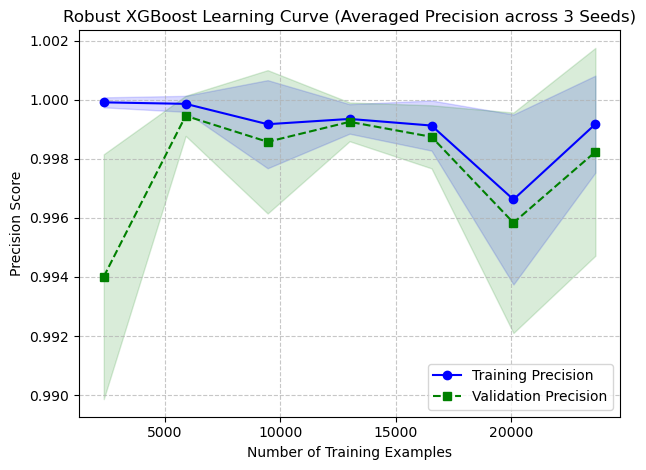

In [ ]:
print("Plotting the results...")

plt.plot(train_sizes, train_mean, color='blue', marker='o', label='Training Precision')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')

plt.plot(train_sizes, test_mean, color='green', marker='s', linestyle='--', label='Validation Precision')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color='green')

plt.title('XGBoost Learning Curve (Averaged Precision across 3 Seeds)')
plt.xlabel('Number of Training Examples')
plt.ylabel('Precision Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

Leander gave me some important information: PCA calculates correlation between columns and erases the ones that have relatively high ones, which can delete some important information. There's also a matching problem when the model will have to predict molecules with higher dimensions. So we're gonna switch to Skbest.

In [13]:
print(" Extracting raw features and SMILES groups...")
X_fp_raw = np.vstack(mega_df_v4['Sample Fingerprint'].values)
X_solvent = np.vstack(mega_df_v4['Solvent'].values)
X_matrix = np.vstack(mega_df_v4['Matrix_Packed_Array'].values)
y = mega_df_v4['Soluble'].values.astype(int)
groups = mega_df_v4['SMILES'].values  # We need the SMILES to group them!

print(" SPLIT: Keeping molecules completely grouped...") #leak proof
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=68)
train_idx, test_idx = next(gss.split(X_fp_raw, y, groups))

# Split all arrays using the safe grouped indices
X_fp_train, X_fp_test = X_fp_raw[train_idx], X_fp_raw[test_idx]
X_sol_train, X_sol_test = X_solvent[train_idx], X_solvent[test_idx]
X_mat_train, X_mat_test = X_matrix[train_idx], X_matrix[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train = groups[train_idx] # We save this for the learning curve later

 Extracting raw features and SMILES groups...
 SPLIT: Keeping molecules completely grouped...


In [23]:
# SKBest fitting here
print(" Fitting SelectKBest on train data...")
k_best = SelectKBest(score_func=chi2, k=200)

# fit_transform on train (it learns the best bits here)
X_fp_train_best = k_best.fit_transform(X_fp_train, y_train)

# transform ONLY on test (it applies the bits it learned without peeking)
X_fp_test_best = k_best.transform(X_fp_test)

print(" Gluing the safe features together...")
X_train_final = np.hstack((X_fp_train_best, X_sol_train, X_mat_train))
X_test_final = np.hstack((X_fp_test_best, X_sol_test, X_mat_test))

 Fitting SelectKBest on train data...
 Gluing the safe features together...


In [24]:
xgb_model = xgboost.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=54,
    eval_metric='logloss'
)

xgb_model.fit(X_train_final, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [25]:
print(" Testing the model...")
y_pred = xgb_model.predict(X_test_final)

accuracy = accuracy_score(y_test, y_pred)
print(f"\n--- SELECT K BEST RESULTS ---")
print(f"Overall Accuracy: {accuracy * 100:.2f}%\n")
print(classification_report(y_test, y_pred))

 Testing the model...

--- SELECT K BEST RESULTS ---
Overall Accuracy: 72.26%

              precision    recall  f1-score   support

           0       0.48      0.33      0.39      2058
           1       0.78      0.87      0.82      5537

    accuracy                           0.72      7595
   macro avg       0.63      0.60      0.61      7595
weighted avg       0.70      0.72      0.70      7595



Lets establish two learning curves: one that changes the trainin data set and one that modifies the amount of k selectors.

Starting Multi-Seed, Zero-Leakage Dual Analysis...

--- Running Pipeline for Random Seed: 42 ---
  -> Calculating Data Size Curve (k=100)...
  -> Calculating K-Features Validation Curve...

--- Running Pipeline for Random Seed: 123 ---
  -> Calculating Data Size Curve (k=100)...
  -> Calculating K-Features Validation Curve...

--- Running Pipeline for Random Seed: 999 ---
  -> Calculating Data Size Curve (k=100)...
  -> Calculating K-Features Validation Curve...

All seeds complete! Averaging data and building plots...


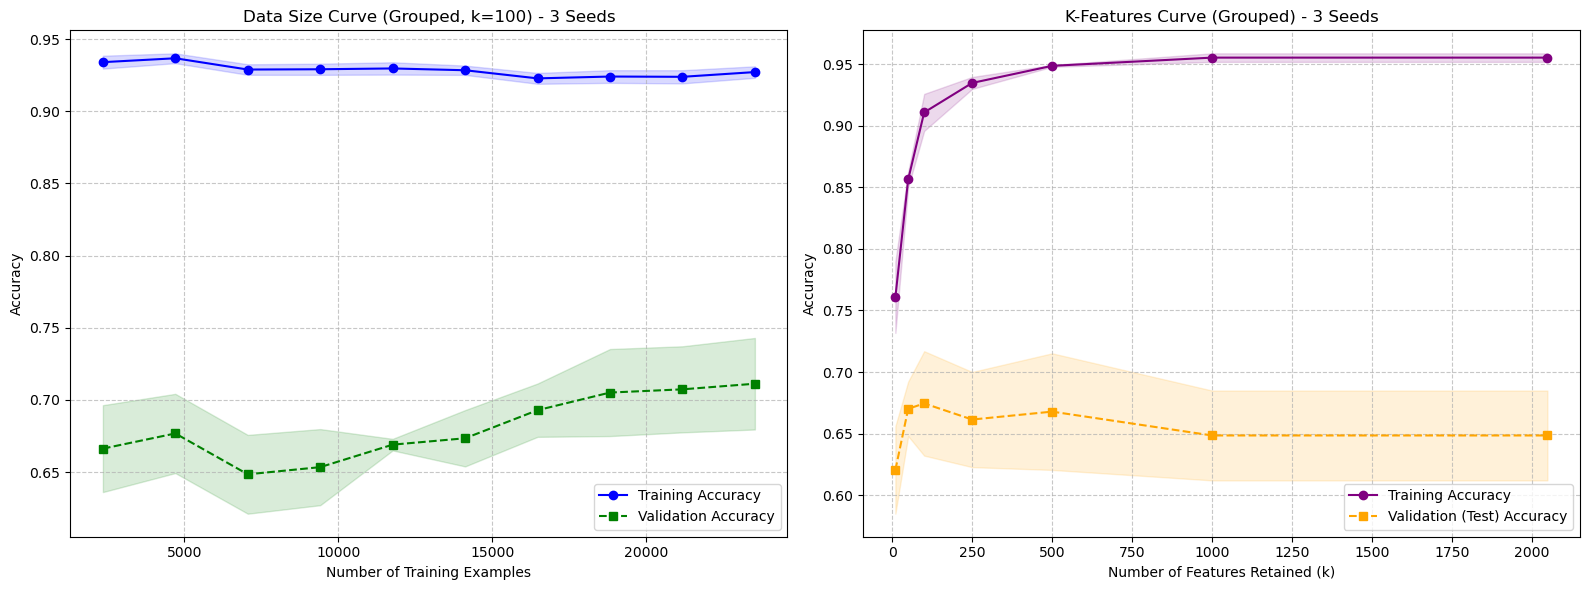

In [12]:
learning_curve_trainsize_kselectors(mega_df_v4)

**<u><span style="font-size:18px">Ablation studies XGBoost</span><u>**

Next step is running similar ablation studies as before but with XGBoost.

In [21]:
df_results = run_ablation_xgboost(mega_df_v4, None)

  AVAILABLE FEATURES TO REMOVE:
  - Sample Fingerprint
  - RT
  - logS
  - Solvent
  - Matrix_Packed_Array
  - None (Keep all features)

Removing [Solvent] from model...
Matrix shape after removal: (36930, 2057)
   -> Results saved to /Users/arthurbenard/Project 1B/src/analysis/model_analysis_results/ablation_XGBOOST_no_Solvent.txt



In [ ]:
df_none = run_ablation_xgboost(mega_df_v4, features_to_remove='None')
df_rt = run_ablation_xgboost(mega_df_v4, features_to_remove='RT')
df_logs = run_ablation_xgboost(mega_df_v4, features_to_remove='logS')
df_sol = run_ablation_xgboost(mega_df_v4, features_to_remove='Solvent')
df_mid = run_ablation_xgboost(mega_df_v4, features_to_remove='Matrix_Packed_Array')
df_fp = run_ablation_xgboost(mega_df_v4, features_to_remove='Sample Fingerprint')
df_fp_rt = run_ablation_xgboost(mega_df_v4, features_to_remove='Sample Fingerprint, RT')
df_rt_logs = run_ablation_xgboost(mega_df_v4, features_to_remove='logS, RT')
df_rt_mid = run_ablation_xgboost(mega_df_v4, features_to_remove='Matrix_Packed_Array, RT')


Plot successfully saved to /Users/arthurbenard/Project 1B/src/analysis/model_analysis_results/Ablation_SuperPlot.png


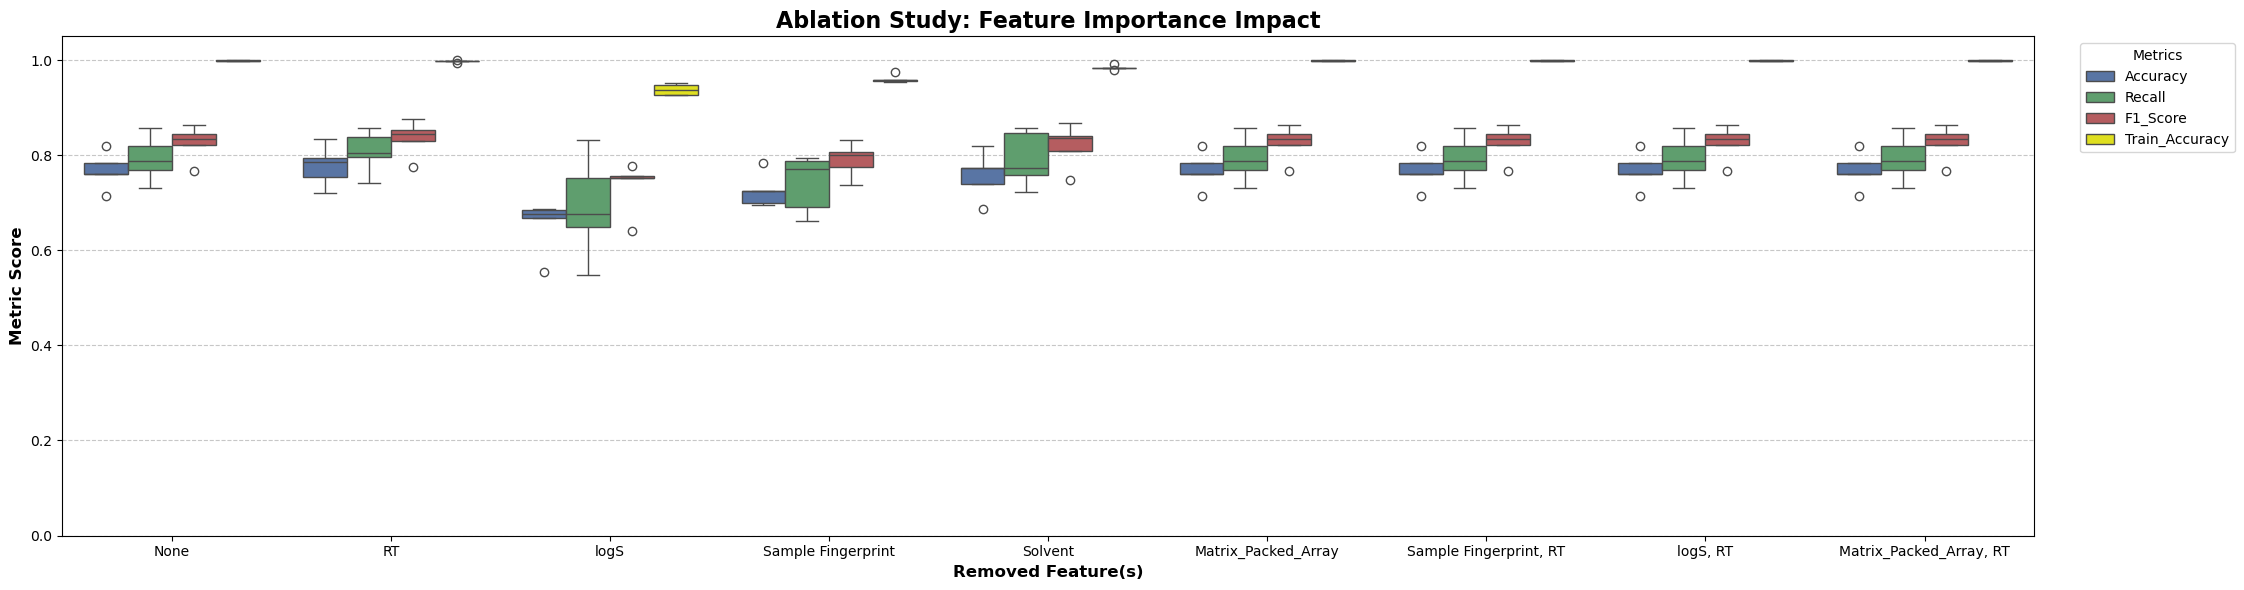

In [23]:
# Glue them together into one massive DataFrame
all_results_df = pd.concat([df_none, df_rt, df_logs, df_fp,  df_sol, df_mid, df_fp_rt, df_rt_logs, df_rt_mid], ignore_index=True)

plot_comparison(all_results_df)

**<u><span style="font-size:18px">Improving XGBoost, descriptors and hyperparameters</span><u>**

The aim here is to improve XGBoost. We're going to add more Descriptors to the dataframe and see how it improves and which improves it better.

This cell will create three new columns, containing the following descriptors: Octanol-Water Partition Coefficient, Topological Polar Surface Area, Molecular Weight, H-bond donors and acceptors. 

In [ ]:
df_desc = mega_df_v4.copy()
df_desc[['MolLogP', 'TPSA', 'MolWt' , 'NumHDonors', 'NumHAcceptors']] = df_desc['SMILES'].apply(calculate_descriptors)
print("Extraction complete")

Extraction complete
              SMILES  MolLogP  TPSA    MolWt  NumHDonors  NumHAcceptors
0  CC(C1=CC=CC=C1)Br   3.1425   0.0  185.064         0.0            0.0
1  CC(C1=CC=CC=C1)Br   3.1425   0.0  185.064         0.0            0.0
2  CC(C1=CC=CC=C1)Br   3.1425   0.0  185.064         0.0            0.0
3  CC(C1=CC=CC=C1)Br   3.1425   0.0  185.064         0.0            0.0
4  CC(C1=CC=CC=C1)Br   3.1425   0.0  185.064         0.0            0.0


This new dataframe will serve as the base for the comparison step. We're going to let the accuracies compete based on which descriptors were used to train the model.

Apparently scaling is necessary to avoid the model to freak out when it sees big values (e.g MW) compared to binary values, risking to judge the descriptor as much more important. StandardScaler squashes the values into more "manageable" ones (uses z-score formula).

In [16]:
tournament_results = run_descriptor_competition(df_desc, 200)

 Preparing Data, Splitting, and Scaling (Leakage-Free)...
 -> Calculated scale_pos_weight: 0.45
 Running the Descriptor Tournament...

             TOURNAMENT RESULTS                   
                                       Experiment  Accuracy  Precision
                     1. Baseline (No Descriptors)  0.774194   0.743590
                            2. Baseline + MolLogP  0.722581   0.696000
                               3. Baseline + TPSA  0.735484   0.762887
                              4. Baseline + MolWt  0.690323   0.680328
                        5. Baseline + LogP + TPSA  0.729032   0.755102
                       6. Baseline + LogP + MolWt  0.683871   0.666667
                       7. Baseline + TPSA + MolWt  0.767742   0.769231
       8. Baseline + H-Bonds (Donors & Acceptors)  0.761290   0.743363
9. Baseline + TPSA + H-Bonds (Donors & Acceptors)  0.735484   0.752475
                                        10. All 5  0.729032   0.727273


In [17]:
tournament_results = run_descriptor_competition(df_desc, 100)

 Preparing Data, Splitting, and Scaling (Leakage-Free)...
 -> Calculated scale_pos_weight: 0.45
 Running the Descriptor Tournament...

             TOURNAMENT RESULTS                   
                                       Experiment  Accuracy  Precision
                     1. Baseline (No Descriptors)  0.683871   0.704762
                            2. Baseline + MolLogP  0.683871   0.680672
                               3. Baseline + TPSA  0.670968   0.720430
                              4. Baseline + MolWt  0.664516   0.700000
                        5. Baseline + LogP + TPSA  0.664516   0.717391
                       6. Baseline + LogP + MolWt  0.638710   0.655172
                       7. Baseline + TPSA + MolWt  0.709677   0.728155
       8. Baseline + H-Bonds (Donors & Acceptors)  0.690323   0.689655
9. Baseline + TPSA + H-Bonds (Donors & Acceptors)  0.683871   0.726316
                                        10. All 5  0.709677   0.711712


After testing these parameters, it seems we'll keep working with the baseline while adding TPSA and molecular weight. Now what is left is maxing out the hyperparameters. We'll look at n_estimators, learning_rate, max_depth, subsample, colsample_bytree, gamma, min_child_weight, reg_alpha and reg_lambda. Here's what they do:

1. **Speed & Size**

*n_estimators*: How many individual decision trees XGBoost is allowed to build. More trees give the model more chances to learn, but if you have too many, it starts memorizing noise.

*learning_rate*: How aggressively the model corrects its mistakes after each tree. A high rate makes wild leaps. A low rate (0.01 to 0.1) takes careful, steady steps.

*max_depth*: How many "questions" deep a single tree can go. max_depth: 3 asks very broad questions. max_depth: 7 asks ultra-specific, branchy questions that risk overfitting.

2. **The Randomizers**

*subsample* (Row Hiding): If set to 0.8, XGBoost randomly hides 20% of your molecules from every single tree. This prevents the model from relying heavily on a few weird outlier chemicals.

*colsample_bytree* (Column Hiding): If set to 0.7, every tree randomly ignores 30% of your features (fingerprint bits, TPSA, MolWt). It forces the model to discover "backup" patterns instead of always using the loudest fingerprint bit.

3. **The "Turbo" Safety Guards**
These are the heavy-duty regularization tools added to try and break the 80% ceiling. They act as strict teachers, slapping the model's wrist if it tries to overfit.

*gamma* (The Pruner): This tells the model, "Do not create a new branch unless it improves our overall loss by at least this much." If a split only slightly helps, gamma chops it off. It keeps the trees clean and simple.

*min_child_weight* (The Crowd Control): This stops the model from creating highly specific rules for edge cases. If a rule only applies to one or two weird molecules in your dataset, this parameter kills the rule. It forces the model to only care about trends that apply to larger groups.

*reg_alpha* ("The Eraser"): This physically pushes the importance weights of useless features down to exactly zero. If 150 of your fingerprint bits are just noise, alpha will literally erase them from the math equation.

*reg_lambda* ("The Smoother"): This prevents any single feature from becoming too powerful. Even if TPSA is your best feature, lambda stops the model from putting 99% of its faith in it, forcing it to spread the workload to other features.

*This cell below did not have the last hyperparameters. It also used an old version of the function, one that used GridSearchCV. Adding more hyperparameters would have been too much time-comsuming.*

In [ ]:
best_model, winning_params = run_hyperparameter_competition(df_desc)

1. Locking in 'Baseline + TPSA + MolWt' Dataset...
2. Initializing Leak-Free Grid Search (Optimizing strictly for Precision)...
Fitting 3 folds for each of 360 candidates, totalling 1080 fits

              BEST HYPERPARAMETERS                
learning_rate: 0.05
max_depth: 4
n_estimators: 150
subsample: 1.0

            TUNED CHAMPION RESULTS                
Final Accuracy:  0.7097
Final Precision: 0.7640


*This cell has all the hyperparameters. This version also uses RandomSearchCV, which grants as much results as GridSearchCV but in a shorter time.*

In [12]:
turbo_model, turbo_params = run_hyperparameter_competition(df_desc)

 Locking in 'Baseline + TPSA + MolWt' Dataset...
 Initializing Leak-Free Grid Search (Optimizing strictly for Precision)...
Fitting 3 folds for each of 100 candidates, totalling 300 fits

              BEST HYPERPARAMETERS                
subsample: 0.8
reg_lambda: 10
reg_alpha: 0
n_estimators: 50
min_child_weight: 5
max_depth: 4
learning_rate: 0.1
gamma: 1

            TUNED CHAMPION RESULTS                
Final Accuracy:  0.7226
Final Precision: 0.7952


Let's map out what's really important here.

In [ ]:
# Get the importance scores
importances = turbo_model.feature_importances_

# Figure out the exact lengths of your solvent and matrix arrays dynamically
num_sol = len(df_desc['Solvent'].iloc[0])
num_mat = len(df_desc['Matrix_Packed_Array'].iloc[0])

# Recreate the column names in the EXACT order we stacked them (X_train_champ)
fp_names = [f"Selected_FP_Bit_{i+1}" for i in range(200)]
sol_names = [f"Solvent_Feature_{i+1}" for i in range(num_sol)]
mat_names = [f"Matrix_Feature_{i+1}" for i in range(num_mat)]
desc_names = ["TPSA", "MolWt"]

feature_names = fp_names + sol_names + mat_names + desc_names

# Create a DataFrame and sort it
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
top_10 = importance_df.sort_values(by='Importance', ascending=False).head(10)

# Plot it
plt.figure(figsize=(8, 5))
sns.barplot(data=top_10, x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Features the AI Used (Turbo Model)')
plt.tight_layout()
plt.show()

**<u><span style="font-size:18px">Tuning the model</span><u>**

It has been suggested to map solvent names to their actual physical properties, that way the model knows what he's dealing with and the differences between solvents. We'll use the Dielectric Constant (how well it separates charge) and Hansen Solubility Parameters (a 3D coordinate system of dispersion, polarity, and hydrogen bonding). One small problem, we need to remove the one-hot coding we used since the beginning. I'm going to regroup everything here that way it'll be easier. **UPDATE** --- df generation has been fixed on 08/04, missing RT everywhere now works.

In [6]:
raw_df = pd.read_excel('/Users/arthurbenard/Project 1B/data/Fichier final (RT+sol)_with_smiles.xlsx')
raw_df['SMILES'] = raw_df['solute_smiles'].astype(str).str.strip()

"""sol_matrix = solubility_file_matrix(clean_df, NMR_SOLVENTS)"""
sol_matrix_dirty= pd.read_excel('/Users/arthurbenard/Project 1B/data/Master_Solubility_Matrix.xlsx')
sol_matrix_dirty['SMILES'] = sol_matrix_dirty['solute_smiles'].astype(str).str.strip()

sol_matrix = sol_matrix_dirty.drop_duplicates(subset=['SMILES'], keep='first')

In [7]:
print(f"Rows before filtering: {len(raw_df)}")
raw_df = raw_df[raw_df['RT'] != 0].copy()
print(f"Rows after removing placeholder zeros: {len(raw_df)}")

Rows before filtering: 1057
Rows after removing placeholder zeros: 896


In [8]:
all_dfs_final = []

for sol_name in NMR_SOLVENTS.keys():
    # Construct the exact column name found in your Master_Solubility_Matrix file
    target_col = f"predicted_logS_{sol_name}"
    
    # Check if that specific column exists
    if target_col in sol_matrix.columns:
        # Start with the RAW chromatography data
        temp_raw = raw_df[['SMILES', 'RT', 'Matrix ID Name']].copy()
        
        # Grab the specific solubility column
        temp_sol = sol_matrix[['SMILES', target_col]].copy()
        
        # Merge them safely
        temp = temp_raw.merge(temp_sol, on='SMILES', how='inner')
        
        if len(temp) > 0:
            # Rename target_col to 'logS' for the model
            temp = temp.rename(columns={target_col: 'logS'})
            temp['Solvent_Name'] = sol_name
            temp['Soluble'] = (temp['logS'] >= -2).astype(int)
            
            all_dfs_final.append(temp)
            print(f" Added {sol_name}: {len(temp)} rows (RT is anchored to Matrix)")
        else:
            print(f" {sol_name}: Merge resulted in 0 rows.")
    else:
        print(f" {target_col} not found in sol_matrix columns.")

# Combine everything
df_desc = pd.concat(all_dfs_final, ignore_index=True)

 Added MeOH: 895 rows (RT is anchored to Matrix)
 Added ACN: 895 rows (RT is anchored to Matrix)
 Added DMSO: 895 rows (RT is anchored to Matrix)
 Added DCM: 895 rows (RT is anchored to Matrix)
 Added CHCl3: 895 rows (RT is anchored to Matrix)


In [9]:
# Generate the Matrix_Packed_Array (The One-Hot encoding for setups)
# We must do this based on the 'Matrix ID Name' column so it's unique per setup
matrix_names_unique = sorted(raw_df['Matrix ID Name'].unique())
matrix_map = {name: i for i, name in enumerate(matrix_names_unique)}

In [10]:
def encode_matrix(name):
    arr = np.zeros(len(matrix_names_unique))
    if name in matrix_map:
        arr[matrix_map[name]] = 1
    return arr

df_desc['Matrix_Packed_Array'] = df_desc['Matrix ID Name'].apply(encode_matrix)

In [11]:
# 1. OPTIMIZE SOLVENTS (Only calculate for the 5 unique solvents)
print("1/3 Mapping Solvent Physics...")
unique_solvents = pd.DataFrame({'Solvent_Name': df_desc['Solvent_Name'].unique()})
# Use your exact function syntax
unique_solvents[['Sol_Dielectric', 'Sol_Hansen_D', 'Sol_Hansen_P', 'Sol_Hansen_H']] = unique_solvents['Solvent_Name'].apply(extract_solvent_physics).apply(pd.Series)

# Merge back into the main dataframe
df_desc = df_desc.merge(unique_solvents, on='Solvent_Name', how='left')

1/3 Mapping Solvent Physics...


In [12]:
# 2. OPTIMIZE DESCRIPTORS (Only calculate for the 151 unique SMILES)
print("2/3 Mapping SMILES Descriptors...")
unique_smiles = pd.DataFrame({'SMILES': df_desc['SMILES'].unique()})
# Use your exact function syntax
unique_smiles[['MolLogP', 'TPSA', 'MolWt', 'NumHDonors', 'NumHAcceptors']] = unique_smiles['SMILES'].apply(calculate_descriptors).apply(pd.Series)

# Merge back into the main dataframe
df_desc = df_desc.merge(unique_smiles, on='SMILES', how='left')

2/3 Mapping SMILES Descriptors...


In [13]:
# 3. OPTIMIZE FINGERPRINTS
print("3/3 Generating Structural Fingerprints...")
# Calculate fingerprints once per unique molecule
fp_dict = {smi: smiles_to_fingerprint(smi) for smi in df_desc['SMILES'].unique()}
# Map them instantly to all 36,930 rows
df_desc['Sample Fingerprint'] = df_desc['SMILES'].map(fp_dict)

print(f"\nDATASET GENERATED SUCCESSFULLY")

3/3 Generating Structural Fingerprints...


[14:56:31] DEPRECATION WARNING: please use MorganGenerator
[14:56:31] DEPRECATION WARNING: please use MorganGenerator
[14:56:31] DEPRECATION WARNING: please use MorganGenerator
[14:56:31] DEPRECATION WARNING: please use MorganGenerator
[14:56:31] DEPRECATION WARNING: please use MorganGenerator
[14:56:31] DEPRECATION WARNING: please use MorganGenerator
[14:56:31] DEPRECATION WARNING: please use MorganGenerator
[14:56:31] DEPRECATION WARNING: please use MorganGenerator
[14:56:31] DEPRECATION WARNING: please use MorganGenerator
[14:56:31] DEPRECATION WARNING: please use MorganGenerator
[14:56:31] DEPRECATION WARNING: please use MorganGenerator
[14:56:31] DEPRECATION WARNING: please use MorganGenerator
[14:56:31] DEPRECATION WARNING: please use MorganGenerator
[14:56:31] DEPRECATION WARNING: please use MorganGenerator
[14:56:31] DEPRECATION WARNING: please use MorganGenerator
[14:56:31] DEPRECATION WARNING: please use MorganGenerator
[14:56:31] DEPRECATION WARNING: please use MorganGenerat


DATASET GENERATED SUCCESSFULLY


[14:56:31] DEPRECATION WARNING: please use MorganGenerator
[14:56:31] DEPRECATION WARNING: please use MorganGenerator
[14:56:31] DEPRECATION WARNING: please use MorganGenerator
[14:56:31] DEPRECATION WARNING: please use MorganGenerator
[14:56:32] DEPRECATION WARNING: please use MorganGenerator
[14:56:32] DEPRECATION WARNING: please use MorganGenerator
[14:56:32] DEPRECATION WARNING: please use MorganGenerator
[14:56:32] DEPRECATION WARNING: please use MorganGenerator
[14:56:32] DEPRECATION WARNING: please use MorganGenerator
[14:56:32] DEPRECATION WARNING: please use MorganGenerator
[14:56:32] DEPRECATION WARNING: please use MorganGenerator
[14:56:32] DEPRECATION WARNING: please use MorganGenerator
[14:56:32] DEPRECATION WARNING: please use MorganGenerator
[14:56:32] DEPRECATION WARNING: please use MorganGenerator
[14:56:32] DEPRECATION WARNING: please use MorganGenerator
[14:56:32] DEPRECATION WARNING: please use MorganGenerator
[14:56:32] DEPRECATION WARNING: please use MorganGenerat

In [14]:
# Save as Excel (Requires 'openpyxl' installed)
df_desc.to_excel('Chemistry_Project_Final_Data.xlsx', index=False)

Now let's use the data we worked so hard to find.

In [13]:
# Grab raw arrays
X_fp_raw = np.vstack(df_desc['Sample Fingerprint'].values)
X_mat = np.vstack(df_desc['Matrix_Packed_Array'].values) # Kept as binary categorical

continuous_cols = ['TPSA', 'MolWt', 'Sol_Dielectric', 'Sol_Hansen_D', 'Sol_Hansen_P', 'Sol_Hansen_H', 'RT', 'logS']
X_continuous = df_desc[continuous_cols].values 

y = df_desc['Soluble'].values.astype(int)
groups = df_desc['SMILES'].values

# SECURE SPLIT
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=34)
train_idx, test_idx = next(gss.split(X_fp_raw, y, groups))

y_train, y_test = y[train_idx], y[test_idx]

# Calculate class weight
scale_weight = np.sum(y_train == 0) / np.sum(y_train == 1) if np.sum(y_train == 1) > 0 else 1.0

In [14]:
# Process Fingerprints
k_best = SelectKBest(score_func=chi2, k=200)
X_fp_train_best = k_best.fit_transform(X_fp_raw[train_idx], y_train)
X_fp_test_best = k_best.transform(X_fp_raw[test_idx])


# SCALE ALL CONTINUOUS FEATURES (TPSA, MolWt + Solvent Physics)
scaler = StandardScaler()
X_cont_train_scaled = scaler.fit_transform(X_continuous[train_idx])
X_cont_test_scaled = scaler.transform(X_continuous[test_idx])

# Glue the Final dataset together
X_train_final = np.hstack((X_fp_train_best, X_mat[train_idx], X_cont_train_scaled))
X_test_final = np.hstack((X_fp_test_best, X_mat[test_idx], X_cont_test_scaled))

In [15]:
# Initialize XGBoost with the exact winning parameters from our Turbo Search
physics_model = xgboost.XGBClassifier(
    n_estimators=50,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,  # We didn't explicitly capture this in the printout, 1.0 is default/safe
    gamma=1,
    min_child_weight=5,
    reg_alpha=0,
    reg_lambda=10,
    scale_pos_weight=scale_weight,
    random_state=69, 
    eval_metric='logloss',
    n_jobs=-1
)

# Train the model
physics_model.fit(X_train_final, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [16]:
print("\n==================================================")
print("     🚀 PHYSICS-ENHANCED CHAMPION RESULTS 🚀      ")
print("==================================================")

y_pred = physics_model.predict(X_test_final)

final_acc = accuracy_score(y_test, y_pred)
final_prec = precision_score(y_test, y_pred, zero_division=0)

print(f"Final Accuracy:  {final_acc:.4f}")
print(f"Final Precision: {final_prec:.4f}")
print("==================================================")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))


     🚀 PHYSICS-ENHANCED CHAMPION RESULTS 🚀      
Final Accuracy:  0.8129
Final Precision: 0.8462

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.78      0.77      3087
           1       0.85      0.84      0.84      4508

    accuracy                           0.81      7595
   macro avg       0.81      0.81      0.81      7595
weighted avg       0.81      0.81      0.81      7595



An impressive 86% precision is obtained if colsample_bytree is fixed at 1.0, but 83% is obtained when it's equal to 0.8. This hyperparameter tells the model to ignore (1-n)% of the fingerprint bits per tree to avoid for example one specific fingerprint bit to be too much valued over every else (Loud guy allegory). This acts as a strict moderator. We tell the committee: "For every single decision, I am randomly kicking (1-n)% of the evidence out of the room." Sometimes, that favorite bit gets kicked out. Suddenly, the trees panic, they can't use their favorite shortcut anymore. They are forced to look at the "quieter" evidence—like the new Dielectric Constant or Hansen Polarity—and figure out how to solve the problem using thermodynamics instead of just structure.

So the question remains: **what do we want ?** --> precision

X_train_final shape: (29335, 215)
Number of names generated: 215
Number of importances from model: 215


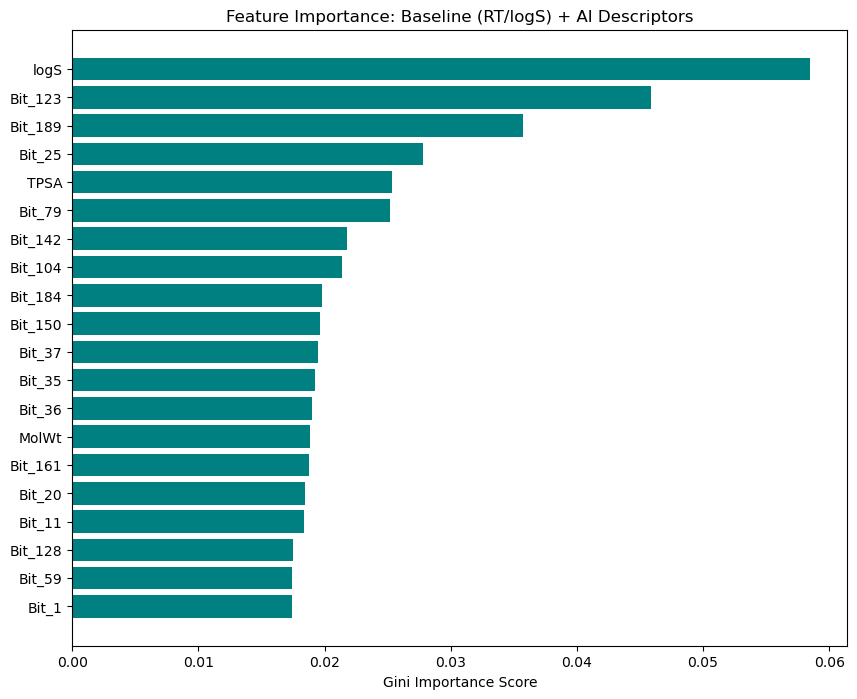

In [ ]:
# Get the raw importance values from the trained model
importances = physics_model.feature_importances_

# Define the counts based on your 'hstack' order
num_fp_bits = X_fp_train_best.shape[1]      # Should be 200
num_mat_cols = X_mat.shape[1]               # The solvent matrix columns
num_cont_cols = len(continuous_cols)        # TPSA, MolWt, Sol_Physics, RT, logS

# Create the labels in the SAME ORDER as your np.hstack
fp_labels = [f"Bit_{i}" for i in range(num_fp_bits)]
mat_labels = [f"Solvent_Mat_{i}" for i in range(num_mat_cols)]
cont_labels = continuous_cols  # These are your 'RT', 'logS', etc.

all_feature_names = fp_labels + mat_labels + cont_labels

# Create DataFrame and Plot
if len(all_feature_names) == len(importances):
    importance_df = pd.DataFrame({
        'Feature': all_feature_names, 
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10, 8))
    plt.barh(importance_df['Feature'][:20], importance_df['Importance'][:20], color='teal')
    plt.gca().invert_yaxis()
    plt.title("Feature Importance: Baseline (RT/logS) + AI Descriptors")
    plt.xlabel("Gini Importance Score")
    plt.show()
else:
    print(" Still a mismatch. Check if X_mat or X_fp_train_best changed size")

*This final cell is to save the exact parameters of the model, scaler and selector used.*

In [76]:
import joblib

print("Saving pipeline objects to disk...")
joblib.dump(physics_model, 'champion_xgb_model.joblib')
joblib.dump(k_best, 'k_best_selector.joblib')
joblib.dump(scaler, 'continuous_scaler.joblib')
print("Export complete!")

Saving pipeline objects to disk...
Export complete!


**<u><span style="font-size:18px">Testing out different models (A,B,C,D)</span><u>**

**Creating Model A**

In [42]:
# 1. PREPARE DATA (As you had it)
y = df_desc['Soluble'].values
X_fp = np.vstack(df_desc['Sample Fingerprint'].values)
cols_A = ['MolLogP', 'TPSA', 'MolWt', 'Sol_Dielectric', 'Sol_Hansen_D', 'Sol_Hansen_P', 'Sol_Hansen_H']

scaler_A = StandardScaler()
X_cont_A = scaler_A.fit_transform(df_desc[cols_A].values)
X_A = np.hstack((X_fp, X_cont_A))

# 2. SPLIT
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=54)
train_idx, test_idx = next(gss.split(df_desc, y, groups=df_desc['SMILES']))

y_train, y_test = y[train_idx], y[test_idx]
scale_weight = (len(y_train) - sum(y_train)) / sum(y_train)

# --- 🚀 ADDED: SELECTKBEST (TOP 200) ---
selector = SelectKBest(score_func=f_classif, k=200)

# We fit the selector on the TRAIN set and apply it to both
X_train_A_best = selector.fit_transform(X_A[train_idx], y_train)
X_test_A_best = selector.transform(X_A[test_idx])

# 3. TRAIN (Using the 'best' version of X)
model_A = xgboost.XGBClassifier(
    n_estimators=50, learning_rate=0.05, max_depth=4, subsample=0.8,
    colsample_bytree=1.0, gamma=1, min_child_weight=5, reg_lambda=10,
    scale_pos_weight=scale_weight, random_state=69, eval_metric='logloss', n_jobs=-1
)
model_A.fit(X_train_A_best, y_train)

# 4. EVALUATE
y_pred_A = model_A.predict(X_test_A_best)
print(f"Model A (Top 200) - Accuracy:  {accuracy_score(y_test, y_pred_A):.4f}")
print(f"Model A (Top 200) - Precision: {precision_score(y_test, y_pred_A, zero_division=0):.4f}\n")

# 5. IMPORTANCE (Updated to handle the 200 selected features)
# Create a list of all original names first
original_names = [f"FP_{i}" for i in range(X_fp.shape[1])] + cols_A
# Use the 'selector' mask to pick only the names of the 200 features we kept
selected_names = np.array(original_names)[selector.get_support()]

imp_A = pd.DataFrame({'Feature': selected_names, 'Importance': model_A.feature_importances_})

print("TOP 10 FEATURES IN MODEL A:")
print(imp_A.sort_values(by='Importance', ascending=False).head(10).to_string(index=False))

Model A (Top 200) - Accuracy:  0.8089
Model A (Top 200) - Precision: 0.9453

TOP 10 FEATURES IN MODEL A:
       Feature  Importance
          TPSA    0.235221
        FP_442    0.157498
       FP_1602    0.096402
        FP_310    0.095731
         MolWt    0.074004
Sol_Dielectric    0.061412
       FP_1057    0.046972
       FP_1754    0.046376
        FP_114    0.028063
       FP_1088    0.027915


**Creating Model B**

In [41]:
# THE TARGET
y = df_desc['Soluble'].values

# EXTRACT ARRAY FEATURES
X_mat = np.vstack(df_desc['Matrix_Packed_Array'].values)
X_fp = np.vstack(df_desc['Sample Fingerprint'].values)

# TRAIN/TEST SPLIT (Grouped by SMILES to prevent leakage)
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=54)
train_idx, test_idx = next(gss.split(df_desc, y, groups=df_desc['SMILES']))

# Extract the target variables
y_train = y[train_idx]
y_test = y[test_idx]

# Calculate scale weight
scale_weight = (len(y_train) - sum(y_train)) / sum(y_train)

# PREPARE CONTINUOUS COLUMNS (Physical descriptors removed, ONLY RT remains)
cols_B = ['RT']

# Extract RAW continuous data for train and test separately
X_cont_train_raw = df_desc[cols_B].iloc[train_idx].values
X_cont_test_raw = df_desc[cols_B].iloc[test_idx].values

# SCALE PROPERLY (Fit ONLY on Train, Transform Test)
scaler_B = StandardScaler()
X_cont_train_scaled = scaler_B.fit_transform(X_cont_train_raw)
X_cont_test_scaled = scaler_B.transform(X_cont_test_raw)  

# COMBINE FEATURES
# Stack the Matrices and the Scaled RT
X_train_B = np.hstack((X_mat[train_idx], X_cont_train_scaled))
X_test_B = np.hstack((X_mat[test_idx], X_cont_test_scaled))

# For Model B, we only have ~12 features now, so we pick the best 10 
num_to_pick = min(10, X_train_B.shape[1]) 
selector = SelectKBest(score_func=f_classif, k=num_to_pick)

# Fit on train, transform both
X_train_B_best = selector.fit_transform(X_train_B, y_train)
X_test_B_best = selector.transform(X_test_B)

# TRAIN MODEL B
model_B = xgboost.XGBClassifier(
    n_estimators=50, learning_rate=0.05, max_depth=4, subsample=0.8,
    colsample_bytree=1.0, gamma=1, min_child_weight=5, reg_lambda=10,
    scale_pos_weight=scale_weight, random_state=69, eval_metric='logloss', n_jobs=-1
)

model_B.fit(X_train_B_best, y_train)

# TEST AND EVALUATE
y_pred_B = model_B.predict(X_test_B_best)

print(f"Model B - Accuracy:  {accuracy_score(y_test, y_pred_B):.4f}")
print(f"Model B - Precision: {precision_score(y_test, y_pred_B, zero_division=0):.4f}\n")

# FEATURE IMPORTANCE
names_B_all = [f"Matrix_{i}" for i in range(X_mat.shape[1])] + cols_B
names_B_selected = np.array(names_B_all)[selector.get_support()]

imp_B = pd.DataFrame({'Feature': names_B_selected, 'Importance': model_B.feature_importances_})
print("TOP FEATURES IN MODEL B:")
print(imp_B.sort_values(by='Importance', ascending=False).head(10).to_string(index=False))

Model B - Accuracy:  0.5747
Model B - Precision: 0.9006

TOP FEATURES IN MODEL B:
 Feature  Importance
      RT    0.207991
Matrix_1    0.182530
Matrix_2    0.178711
Matrix_4    0.130381
Matrix_0    0.100309
Matrix_5    0.100256
Matrix_6    0.099822
Matrix_3    0.000000


**Creating Model C**

In [43]:
# Define columns (including everything)
cols_C = ['RT', 'MolLogP', 'TPSA', 'MolWt', 
          'Sol_Dielectric', 'Sol_Hansen_D', 'Sol_Hansen_P', 'Sol_Hansen_H']

# EXTRACT RAW CONTINUOUS DATA FOR TRAIN AND TEST SEPARATELY
X_cont_train_raw_C = df_desc[cols_C].iloc[train_idx].values
X_cont_test_raw_C = df_desc[cols_C].iloc[test_idx].values

# SCALE PROPERLY (Fit ONLY on Train, Transform Test)
scaler_C = StandardScaler()
X_cont_train_scaled_C = scaler_C.fit_transform(X_cont_train_raw_C)
X_cont_test_scaled_C = scaler_C.transform(X_cont_test_raw_C)

# COMBINE ALL FEATURES SAFELY
X_train_C = np.hstack((X_fp[train_idx], X_mat[train_idx], X_cont_train_scaled_C))
X_test_C = np.hstack((X_fp[test_idx], X_mat[test_idx], X_cont_test_scaled_C))

# ---  SELECTKBEST (THE TOP 200 FILTER) ---
# This picks the 200 features with the highest correlation to solubility
selector = SelectKBest(score_func=f_classif, k=200)

# Fit ONLY on Train, then transform both
X_train_C_best = selector.fit_transform(X_train_C, y_train)
X_test_C_best = selector.transform(X_test_C)

# Train Model C
model_C = xgboost.XGBClassifier(
    n_estimators=50, learning_rate=0.05, max_depth=4, subsample=0.8,
    colsample_bytree=1.0, gamma=1, min_child_weight=5, reg_lambda=10,
    scale_pos_weight=scale_weight, random_state=69, eval_metric='logloss', n_jobs=-1
)

# Use the 'best' training data
model_C.fit(X_train_C_best, y_train)

# Use the 'best' test data
y_pred_C = model_C.predict(X_test_C_best)

print(f"Model C (Top 200) - Accuracy:  {accuracy_score(y_test, y_pred_C):.4f}")
print(f"Model C (Top 200) - Precision: {precision_score(y_test, y_pred_C, zero_division=0):.4f}\n")

# Importance for Model C
num_fingerprints = X_fp.shape[1]
names_C_all = [f"FP_{i}" for i in range(num_fingerprints)] + \
              [f"Matrix_{i}" for i in range(X_mat.shape[1])] + cols_C

# Filter the names list to match only the 200 features we kept
names_C_selected = np.array(names_C_all)[selector.get_support()]

imp_C = pd.DataFrame({'Feature': names_C_selected, 'Importance': model_C.feature_importances_})
print("\n TOP 15 FEATURES IN MODEL C (Post-Selection):")
print(imp_C.sort_values(by='Importance', ascending=False).head(15).to_string(index=False))

Model C (Top 200) - Accuracy:  0.8201
Model C (Top 200) - Precision: 0.9460


 TOP 15 FEATURES IN MODEL C (Post-Selection):
       Feature  Importance
          TPSA    0.226327
        FP_442    0.178898
        FP_310    0.094227
       FP_1602    0.091948
         MolWt    0.069263
Sol_Dielectric    0.061490
       FP_1057    0.047523
       FP_1754    0.039194
        FP_114    0.030634
        FP_352    0.024654
            RT    0.024489
       FP_1088    0.023802
        FP_695    0.023126
        FP_314    0.022538
       FP_1844    0.014674


**Creating Model D**

In [44]:
# 1. EXTRACT RAW DATA
# We use the global train_idx from your split!
X_train_D_raw = X_fp[train_idx]
X_test_D_raw = X_fp[test_idx]

# Notice: No StandardScaler! Fingerprints are just 1s and 0s, they don't need scaling.

# 2. SELECTKBEST (The Top 200 Filter)
# We have 2048 features, so we filter it down to the smartest 200 bits
selector_D = SelectKBest(score_func=f_classif, k=200)

X_train_D_best = selector_D.fit_transform(X_train_D_raw, y_train)
X_test_D_best = selector_D.transform(X_test_D_raw)

# 3. TRAIN MODEL D
model_D = xgboost.XGBClassifier(
    n_estimators=50, learning_rate=0.05, max_depth=4, subsample=0.8,
    colsample_bytree=1.0, gamma=1, min_child_weight=5, reg_lambda=10,
    scale_pos_weight=scale_weight, random_state=69, eval_metric='logloss', n_jobs=-1
)
model_D.fit(X_train_D_best, y_train)

# 4. EVALUATE
y_pred_D = model_D.predict(X_test_D_best)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_D):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_D, zero_division=0):.4f}\n")

# 5. FEATURE IMPORTANCE
num_fingerprints = X_fp.shape[1]
names_D_all = [f"FP_{i}" for i in range(num_fingerprints)]
names_D_selected = np.array(names_D_all)[selector_D.get_support()]

imp_D = pd.DataFrame({'Feature': names_D_selected, 'Importance': model_D.feature_importances_})
print("TOP 10 FINGERPRINTS IN MODEL D:")
print(imp_D.sort_values(by='Importance', ascending=False).head(10).to_string(index=False))

Accuracy:  0.8290
Precision: 0.9316

TOP 10 FINGERPRINTS IN MODEL D:
Feature  Importance
 FP_168    0.067226
FP_1057    0.063418
FP_1928    0.062947
FP_1917    0.058342
FP_1088    0.052782
  FP_25    0.051077
FP_1737    0.044692
  FP_80    0.042808
 FP_650    0.042471
 FP_352    0.042468


**Comparing Features**

In [45]:
# Look at Model B
print("\n MODEL B:")
rt_mat_B = imp_B[imp_B['Feature'].str.contains('RT|Matrix', case=False)].copy()
print(rt_mat_B.head(10).to_string(index=False))

# Look at Model C
print("\n MODEL C:")
rt_mat_C = imp_C[imp_C['Feature'].str.contains('RT|Matrix', case=False)].copy()
print(rt_mat_C.head(10).to_string(index=False))


 MODEL B:
 Feature  Importance
Matrix_0    0.100309
Matrix_1    0.182530
Matrix_2    0.178711
Matrix_3    0.000000
Matrix_4    0.130381
Matrix_5    0.100256
Matrix_6    0.099822
      RT    0.207991

 MODEL C:
Feature  Importance
     RT    0.024489


**<u><span style="font-size:18px">Learning Curve for Models A,B,C,D</span><u>**

NameError: name 'df_desc' is not defined

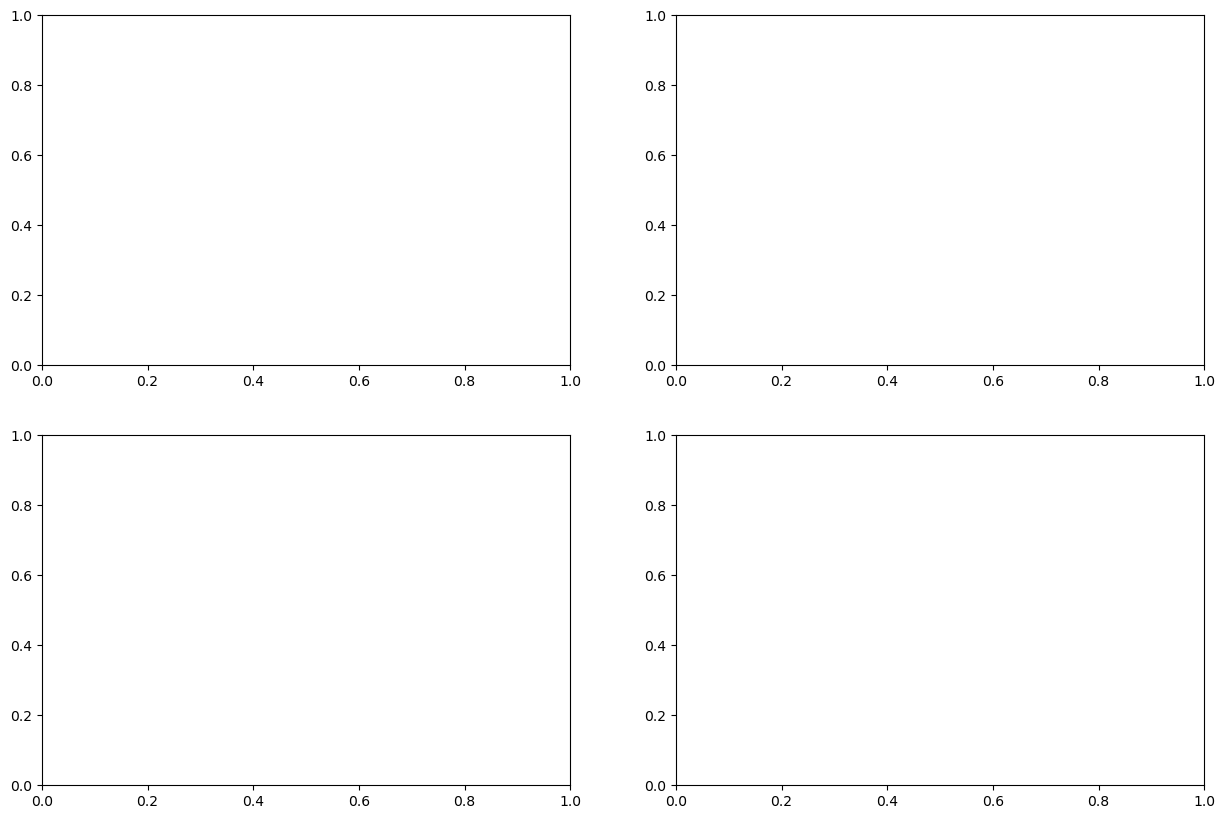

In [6]:
def plot_learning_curve(estimator, X, y, groups, title, ax):
    # This ensures the 20% subset has a healthy mix of all solvents/matrices.
    shuffle_idx = np.random.permutation(len(y))
    X_shuf = X[shuffle_idx]
    y_shuf = y[shuffle_idx]
    groups_shuf = groups.iloc[shuffle_idx]

    gkf = GroupKFold(n_splits=5)

    # Calculate learning curve data (Using 5-fold cross validation on the training set)
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X_shuf, y_shuf, cv=gkf, groups=groups_shuf, n_jobs=-1, 
        train_sizes=np.linspace(0.02, 1.0, 5), scoring='accuracy'
    )
    
    # Calculate means and standard deviations
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    # Plot lines and shaded areas for variance
    ax.plot(train_sizes, train_mean, 'o-', color="blue", label="Training Accuracy")
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")
    
    ax.plot(train_sizes, test_mean, 'o-', color="orange", label="Cross-Validation Accuracy")
    ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="orange")
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel("Number of Training Examples")
    ax.set_ylabel("Accuracy")
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(loc="lower right")
    ax.set_ylim([0, 1.0]) # Lock Y-axis to make comparisons fair

# Create a 2x2 grid for the 4 plots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Flatten the 2x2 array into a simple 1D list so we can just use 0, 1, 2, 3
axes = axes.flatten()

groups_train = df_desc.iloc[train_idx]['SMILES']

# Slot 0: Top Left
plot_learning_curve(model_A, X_train_A_best, y_train, groups_train, "Model A (FP + Physical Descriptors , NO RT/Matrix)", axes[0])

# Slot 1: Top Right
plot_learning_curve(model_B, X_train_B_best, y_train, groups_train, "Model B (RT + Matrix, NO Physical Descriptors and FP)", axes[1])

# Slot 2: Bottom Left
plot_learning_curve(model_C, X_train_C_best, y_train, groups_train, "Model C (Everything Included)", axes[2])

# Slot 3: Bottom Right (The New Baseline)
plot_learning_curve(model_D, X_train_D_best, y_train, groups_train, "Model D (Raw Baseline: FP ONLY)", axes[3])

plt.tight_layout()
plt.show()

**<u><span style="font-size:18px">Spaghetti Plot: where's the RT data?</span><u>**

This next part is part is to determine what is actual RT data put in. Does the RT stay (relatively) constant per molecule even when we change the matrixID (then it makes sense that it's basically irrelevant); or does it vary in a meaningful way per molecule such that there may be a correlation with solubility? (we expect that to be the case to some degree but it would be nice to actually look into ti for a moment)

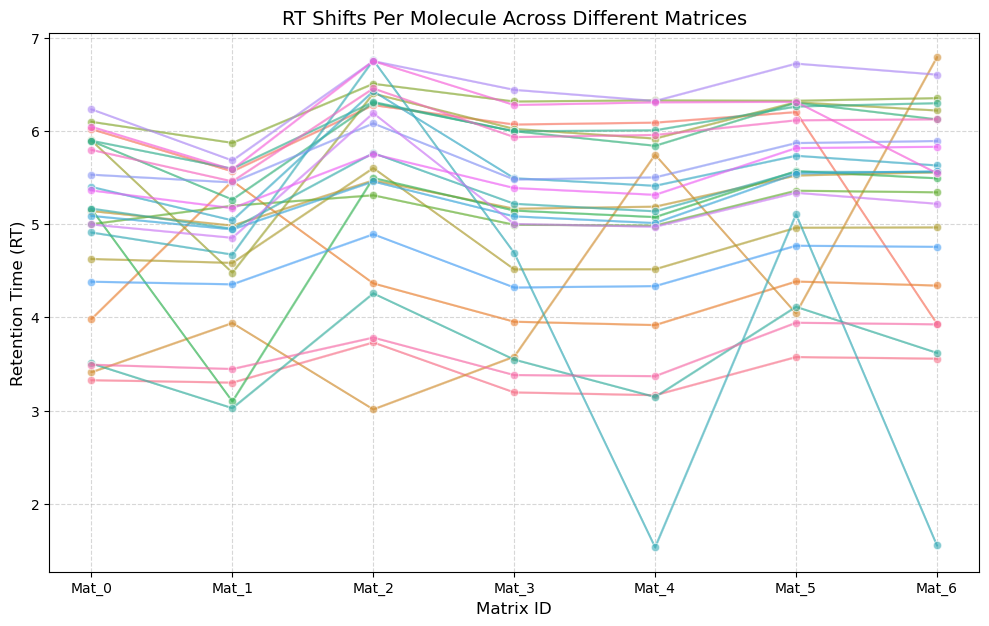

 Average RT deviation for the same molecule across matrices: 0.5300


In [ ]:
# 1. Decode the Matrix ID (similar to before)
matrix_ids = np.argmax(X_mat, axis=1)

# 2. Create a focused dataframe
# We need SMILES to identify the "same" molecule across different runs
df_rt_check = pd.DataFrame({
    'SMILES': df_desc['SMILES'],
    'RT': df_desc['RT'],
    'Matrix_ID': [f"Mat_{i}" for i in matrix_ids]
})

# 3. Filter for molecules that appear in at least 2 different matrices
# (We can't see "change" if the molecule only appears once!)
counts = df_rt_check['SMILES'].value_counts()
multi_matrix_smiles = counts[counts > 1].index
df_filtered = df_rt_check[df_rt_check['SMILES'].isin(multi_matrix_smiles)]

# 4. Plotting
plt.figure(figsize=(12, 7))

# We'll plot lines for the first 25 molecules to keep the graph readable
sample_smiles = multi_matrix_smiles[:25] 
df_plot = df_filtered[df_filtered['SMILES'].isin(sample_smiles)]

sns.lineplot(data=df_plot, x='Matrix_ID', y='RT', hue='SMILES', marker='o', legend=False, alpha=0.6)

plt.title("RT Shifts Per Molecule Across Different Matrices", fontsize=14)
plt.xlabel("Matrix ID", fontsize=12)
plt.ylabel("Retention Time (RT)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 5. Quick Stat for the TA
# Calculate the standard deviation of RT for the same molecule
rt_variance = df_filtered.groupby('SMILES')['RT'].std().mean()
print(f" Average RT deviation for the same molecule across matrices: {rt_variance:.4f}")

This is just to verify if removing the rows worked.

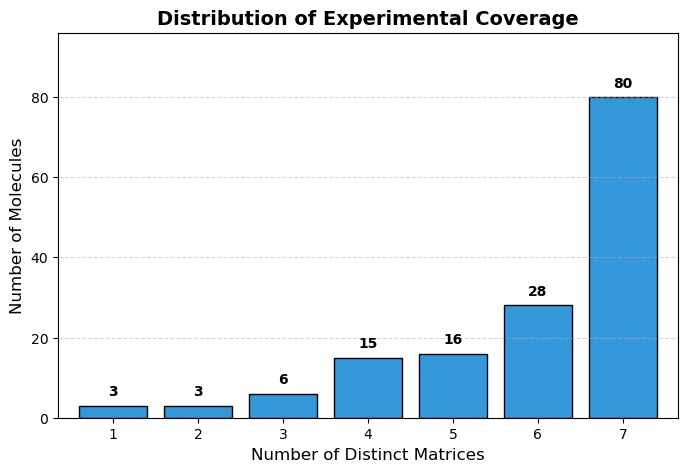

--- Summary Table ---
Matrix ID Name
1     3
2     3
3     6
4    15
5    16
6    28
7    80
Total Unique Molecules: 151


In [29]:
# 1. Calculate how many matrices each molecule has
matrix_counts = df_desc.groupby('SMILES')['Matrix ID Name'].nunique()

# 2. Get the distribution (How many molecules for each count?)
dist = matrix_counts.value_counts().sort_index()

# 3. Plotting
plt.figure(figsize=(8, 5))
ax = dist.plot(kind='bar', color='#3498db', edgecolor='black', width=0.8)

# Add the counts on top of each bar
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontweight='bold')

plt.title("Distribution of Experimental Coverage", fontsize=14, fontweight='bold')
plt.xlabel("Number of Distinct Matrices", fontsize=12)
plt.ylabel("Number of Molecules", fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, dist.max() * 1.2) # Make room for the labels
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# 4. The raw numbers for your notes/TA
print("--- Summary Table ---")
print(dist.to_string())
print(f"Total Unique Molecules: {len(matrix_counts)}")

**<u><span style="font-size:18px">Models 1,2,3,4</span><u>**

The following cells are part of an idea Leander had: to try to force the model to take into account the matrix IDs we'll multiply the one-hot coded vector of the ladder with the RT. But leave the RT in the training.

**Creating Model 1** --> basically the same as Model A

In [24]:
# 1. PREPARE DATA (As you had it)
y = df_desc['Soluble'].values
X_fp = np.vstack(df_desc['Sample Fingerprint'].values)
cols_1 = ['MolLogP', 'TPSA', 'MolWt', 'Sol_Dielectric', 'Sol_Hansen_D', 'Sol_Hansen_P', 'Sol_Hansen_H']
X_cont_raw_1 = df_desc[cols_1].values

# 2. SPLIT
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=54)
train_idx, test_idx = next(gss.split(df_desc, y, groups=df_desc['SMILES']))

y_train, y_test = y[train_idx], y[test_idx]
scale_weight = (len(y_train) - sum(y_train)) / sum(y_train)
groups_train = df_desc.iloc[train_idx]['SMILES']

# ---  SELECTKBEST (TOP 200) ---

scaler_1 = StandardScaler()
X_cont_train_1 = scaler_1.fit_transform(X_cont_raw_1[train_idx])
X_cont_test_1  = scaler_1.transform(X_cont_raw_1[test_idx])

X_train_1_glued = np.hstack((X_fp[train_idx], X_cont_train_1))
X_test_1_glued  = np.hstack((X_fp[test_idx], X_cont_test_1))
# We fit the selector on the TRAIN set and apply it to both
selector_1 = SelectKBest(score_func=f_classif, k=200)
X_train_1_best = selector_1.fit_transform(X_train_1_glued, y_train)
X_test_1_best = selector_1.transform(X_test_1_glued)

# 3. TRAIN (Using the 'best' version of X)
model_1 = xgboost.XGBClassifier(
    n_estimators=50, learning_rate=0.05, max_depth=4, subsample=0.8,
    colsample_bytree=1.0, gamma=1, min_child_weight=5, reg_lambda=10,
    scale_pos_weight=scale_weight, random_state=69, eval_metric='logloss', n_jobs=-1
)
model_1.fit(X_train_1_best, y_train)

# 4. EVALUATE
y_pred_1 = model_1.predict(X_test_1_best)
print(f"Model 1 - Accuracy:  {accuracy_score(y_test, y_pred_1):.4f}")
print(f"Model 1 - Precision: {precision_score(y_test, y_pred_1, zero_division=0):.4f}\n")

# 5. IMPORTANCE (Updated to handle the 200 selected features)
# Create a list of all original names first
original_names = [f"FP_{i}" for i in range(X_fp.shape[1])] + cols_1
# Use the 'selector' mask to pick only the names of the 200 features we kept
selected_names = np.array(original_names)[selector_1.get_support()]

imp_1 = pd.DataFrame({'Feature': selected_names, 'Importance': model_1.feature_importances_})

print("TOP 10 FEATURES IN MODEL A 2.0:")
print(imp_1.sort_values(by='Importance', ascending=False).head(10).to_string(index=False))

Model 1 - Accuracy:  0.8089
Model 1 - Precision: 0.9453

TOP 10 FEATURES IN MODEL A 2.0:
       Feature  Importance
          TPSA    0.235221
        FP_442    0.157498
       FP_1602    0.096402
        FP_310    0.095731
         MolWt    0.074004
Sol_Dielectric    0.061412
       FP_1057    0.046972
       FP_1754    0.046376
        FP_114    0.028063
       FP_1088    0.027915


*Set up for the others*

In [69]:
# 1. THE TARGET
y = df_desc['Soluble'].values

# 2. EXTRACT GLOBAL ARRAYS
X_fp = np.vstack(df_desc['Sample Fingerprint'].values)
X_mat = np.vstack(df_desc['Matrix_Packed_Array'].values)
X_rt = df_desc[['RT']].values 

# THE TA UPGRADE
X_mat_interaction = X_mat * X_rt

# 3. GLOBAL SPLIT (Ensures ALL models see the exact same train/test rows)
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=54)
train_idx, test_idx = next(gss.split(df_desc, y, groups=df_desc['SMILES']))

y_train, y_test = y[train_idx], y[test_idx]
scale_weight = (len(y_train) - sum(y_train)) / sum(y_train)
groups_train = df_desc.iloc[train_idx]['SMILES']

**Creating Model 2**

In [ ]:
cols_2 = ['MolWt', 'Sol_Dielectric', 'Sol_Hansen_D', 'Sol_Hansen_P', 'Sol_Hansen_H']

# Combine RT with the other continuous variables for scaling
X_cont_2 = np.hstack((X_rt, df_desc[cols_2].values))

# Use the new X_mat_interaction instead of X_mat
X_train_2_best = np.hstack((X_cont_2[train_idx], X_mat_interaction[train_idx]))
X_test_2_best = np.hstack((X_cont_2[test_idx], X_mat_interaction[test_idx]))

scaler_2 = StandardScaler()
X_cont_train_2 = scaler_2.fit_transform(X_train_2_best)
X_cont_test_2 = scaler_2.transform(X_test_2_best)


model_2 = xgboost.XGBClassifier(n_estimators=50, learning_rate=0.05, max_depth=4, subsample=0.8,
    colsample_bytree=1.0, gamma=1, min_child_weight=5, reg_lambda=10, scale_pos_weight=scale_weight, random_state=69, n_jobs=-1)
model_2.fit(X_train_2_best, y_train)

y_pred_2 = model_2.predict(X_test_2_best)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_2):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_2, zero_division=0):.4f}\n")

Accuracy:  0.8372
Precision: 0.9345



**Creating Model 3**

In [28]:
cols_3 = ['MolLogP', 'TPSA', 'MolWt', 'Sol_Dielectric', 'Sol_Hansen_D', 'Sol_Hansen_P', 'Sol_Hansen_H']

# 1. SCALE CONTINUOUS DATA (RT + Physics)
X_cont_3 = df_desc[cols_3].values
scaler_3 = StandardScaler()
X_cont_train_3 = scaler_3.fit_transform(X_cont_3[train_idx])
X_cont_test_3 = scaler_3.transform(X_cont_3[test_idx])

# 2. FILTER **ONLY** THE FINGERPRINTS (Trim 2048 down to 200)
selector_3 = SelectKBest(score_func=f_classif, k=200)
X_train_fp_best = selector_3.fit_transform(X_fp[train_idx], y_train)
X_test_fp_best = selector_3.transform(X_fp[test_idx])

# 3. GLUE IT ALL TOGETHER (Best FPs + VIP Physics + VIP Interactions)
X_train_3_best = np.hstack((X_train_fp_best, X_cont_train_3, X_mat_interaction[train_idx]))
X_test_3_best = np.hstack((X_test_fp_best, X_cont_test_3, X_mat_interaction[test_idx]))

model_3 = xgboost.XGBClassifier(n_estimators=50, learning_rate=0.05, max_depth=4, subsample=0.8,
    colsample_bytree=1.0, gamma=1, min_child_weight=5, reg_lambda=10, scale_pos_weight=scale_weight, random_state=69, n_jobs=-1)
model_3.fit(X_train_3_best, y_train)

y_pred_3 = model_3.predict(X_test_3_best)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_3):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_3, zero_division=0):.4f}\n")

list_fp = np.array([f"FP_{i}" for i in range(X_fp.shape[1])])
selected_fps_3 = list(list_fp[selector_3.get_support()])
list_interaction = [f"RT_in_Matrix_{i}" for i in range(X_mat.shape[1])]

selected_names_3 = selected_fps_3 + cols_3 + list_interaction

imp_3 = pd.DataFrame({'Feature': selected_names_3, 'Importance': model_3.feature_importances_})
print("MODEL 3 FEATURE IMPORTANCES:")
# Hide the fingerprints just for the printout so we can see the physics clearly
rt_mat_phys_3 = imp_3[~imp_3['Feature'].str.contains('FP_')].copy()
print(rt_mat_phys_3.sort_values(by='Importance', ascending=False).to_string(index=False))

Accuracy:  0.8208
Precision: 0.9461

MODEL 3 FEATURE IMPORTANCES:
       Feature  Importance
          TPSA    0.232512
         MolWt    0.087887
       MolLogP    0.052483
Sol_Dielectric    0.042346
  Sol_Hansen_H    0.023683
  Sol_Hansen_D    0.022236
  Sol_Hansen_P    0.000000
RT_in_Matrix_0    0.000000
RT_in_Matrix_1    0.000000
RT_in_Matrix_2    0.000000
RT_in_Matrix_3    0.000000
RT_in_Matrix_4    0.000000
RT_in_Matrix_5    0.000000
RT_in_Matrix_6    0.000000


**Creating Model 4** --> basically Model D

In [29]:
# 1. EXTRACT RAW DATA
# We use the global train_idx from your split!
X_train_4_raw = X_fp[train_idx]
X_test_4_raw = X_fp[test_idx]

# Notice: No StandardScaler! Fingerprints are just 1s and 0s, they don't need scaling.

# 2. SELECTKBEST (The Top 200 Filter)
# We have 2048 features, so we filter it down to the smartest 200 bits
selector_4 = SelectKBest(score_func=f_classif, k=200)

X_train_4_best = selector_4.fit_transform(X_train_4_raw, y_train)
X_test_4_best = selector_4.transform(X_test_4_raw)

# 3. TRAIN MODEL D
model_4 = xgboost.XGBClassifier(
    n_estimators=50, learning_rate=0.05, max_depth=4, subsample=0.8,
    colsample_bytree=1.0, gamma=1, min_child_weight=5, reg_lambda=10,
    scale_pos_weight=scale_weight, random_state=69, eval_metric='logloss', n_jobs=-1
)
model_4.fit(X_train_4_best, y_train)

# 4. EVALUATE
y_pred_4 = model_4.predict(X_test_4_best)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_4):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_4, zero_division=0):.4f}\n")

Accuracy:  0.8290
Precision: 0.9316



**<u><span style="font-size:18px">Learning Curves of Models 1,2,3,4</span><u>**

In [37]:
def plot_learning_curve(estimator, X, y, groups, title, ax):
    # SHUFFLE FIX to ensure smooth curves
    shuffle_idx = np.random.permutation(len(y))
    X_shuf = X[shuffle_idx]
    y_shuf = y[shuffle_idx]
    groups_shuf = groups.iloc[shuffle_idx]

    gkf = GroupKFold(n_splits=5)
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X_shuf, y_shuf, cv=gkf, groups=groups_shuf, n_jobs=-1, 
        train_sizes=np.linspace(0.0001, 0.4 , 10), scoring='accuracy'
    )
    
    train_mean, train_std = np.mean(train_scores, axis=1), np.std(train_scores, axis=1)
    test_mean, test_std = np.mean(test_scores, axis=1), np.std(test_scores, axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color="blue", label="Training Accuracy")
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")
    ax.plot(train_sizes, test_mean, 'o-', color="orange", label="CV Accuracy")
    ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="orange")
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel("Number of Training Examples")
    ax.set_ylabel("Accuracy")
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(loc="lower right")
    ax.set_xlim(left=0)
    ax.set_ylim([0, 1.0]) 


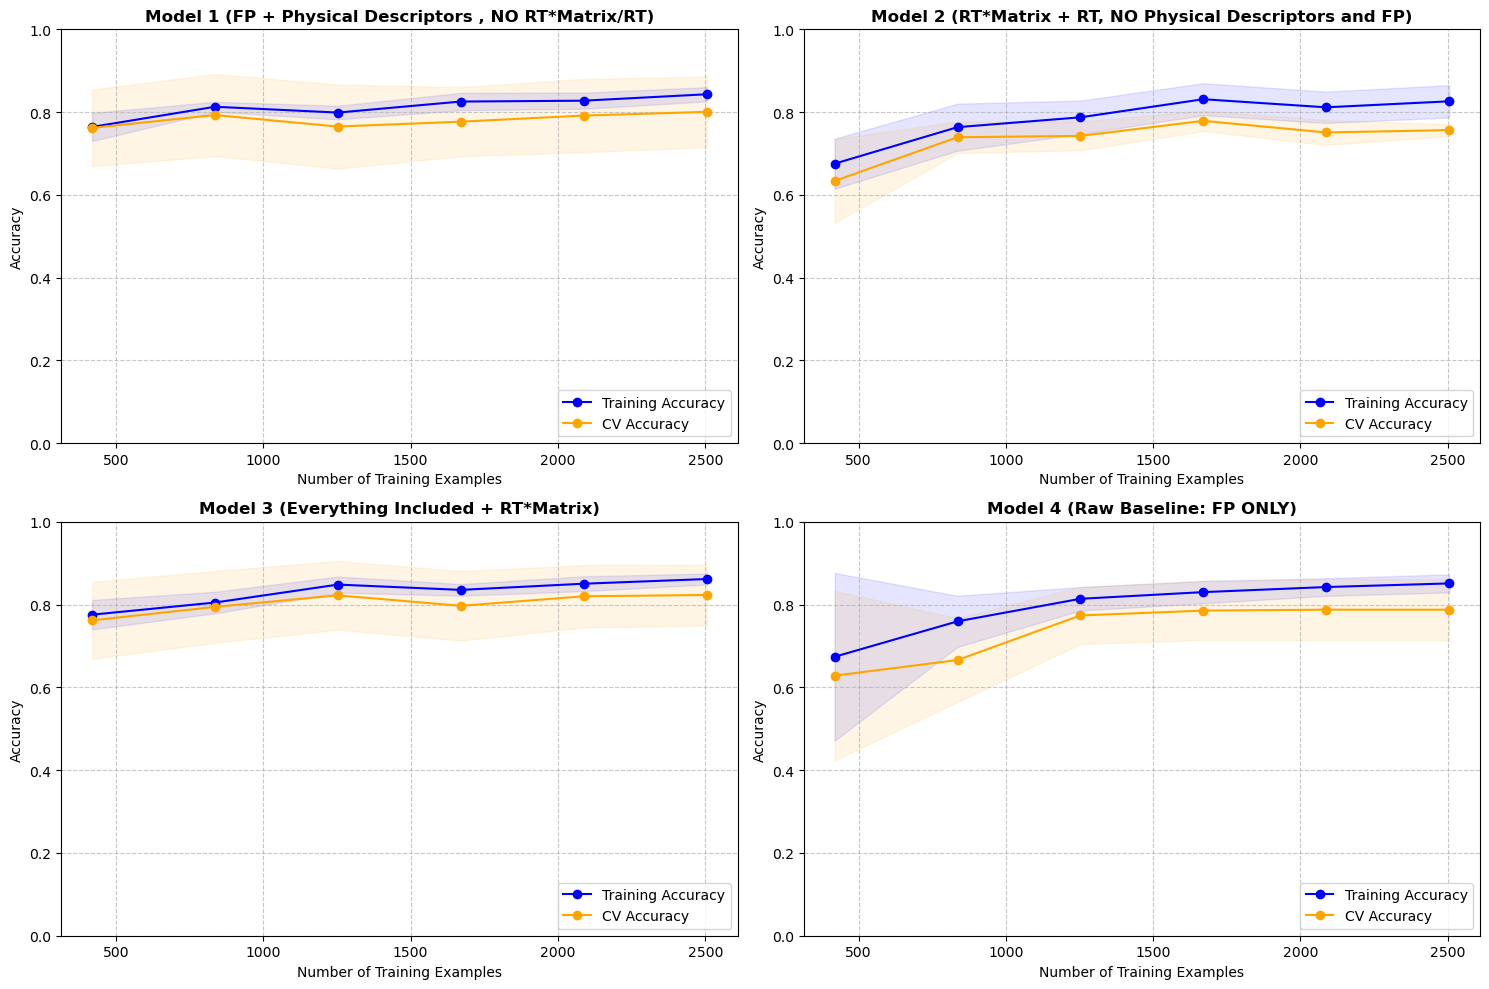

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

plot_learning_curve(model_1, X_train_1_best, y_train, groups_train, "Model 1 (FP + Physical Descriptors , NO RT*Matrix/RT)", axes[0])
plot_learning_curve(model_2, X_train_2_best, y_train, groups_train, "Model 2 (RT*Matrix + RT, NO Physical Descriptors and FP)", axes[1])
plot_learning_curve(model_3, X_train_3_best, y_train, groups_train, "Model 3 (Everything Included + RT*Matrix)", axes[2])
plot_learning_curve(model_4, X_train_4_best, y_train, groups_train, "Model 4 (Raw Baseline: FP ONLY)", axes[3])

plt.tight_layout()
plt.show()

**Weight Importance**

In [53]:
def plot_top_15_weight(model, feature_names, title, ax):
    booster = model.get_booster()
    booster.feature_names = list(feature_names)
    
    # Get the top 15 most important features
    imp = pd.Series(booster.get_score(importance_type='weight')).sort_values(ascending=False).head(15)
    
    if not imp.empty:
        sns.barplot(x=imp.values, y=imp.index, ax=ax, palette="plasma", hue=imp.index, legend=False)
    
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel("Number of Splits (Weight)")
    ax.grid(axis='x', linestyle='--', alpha=0.7)

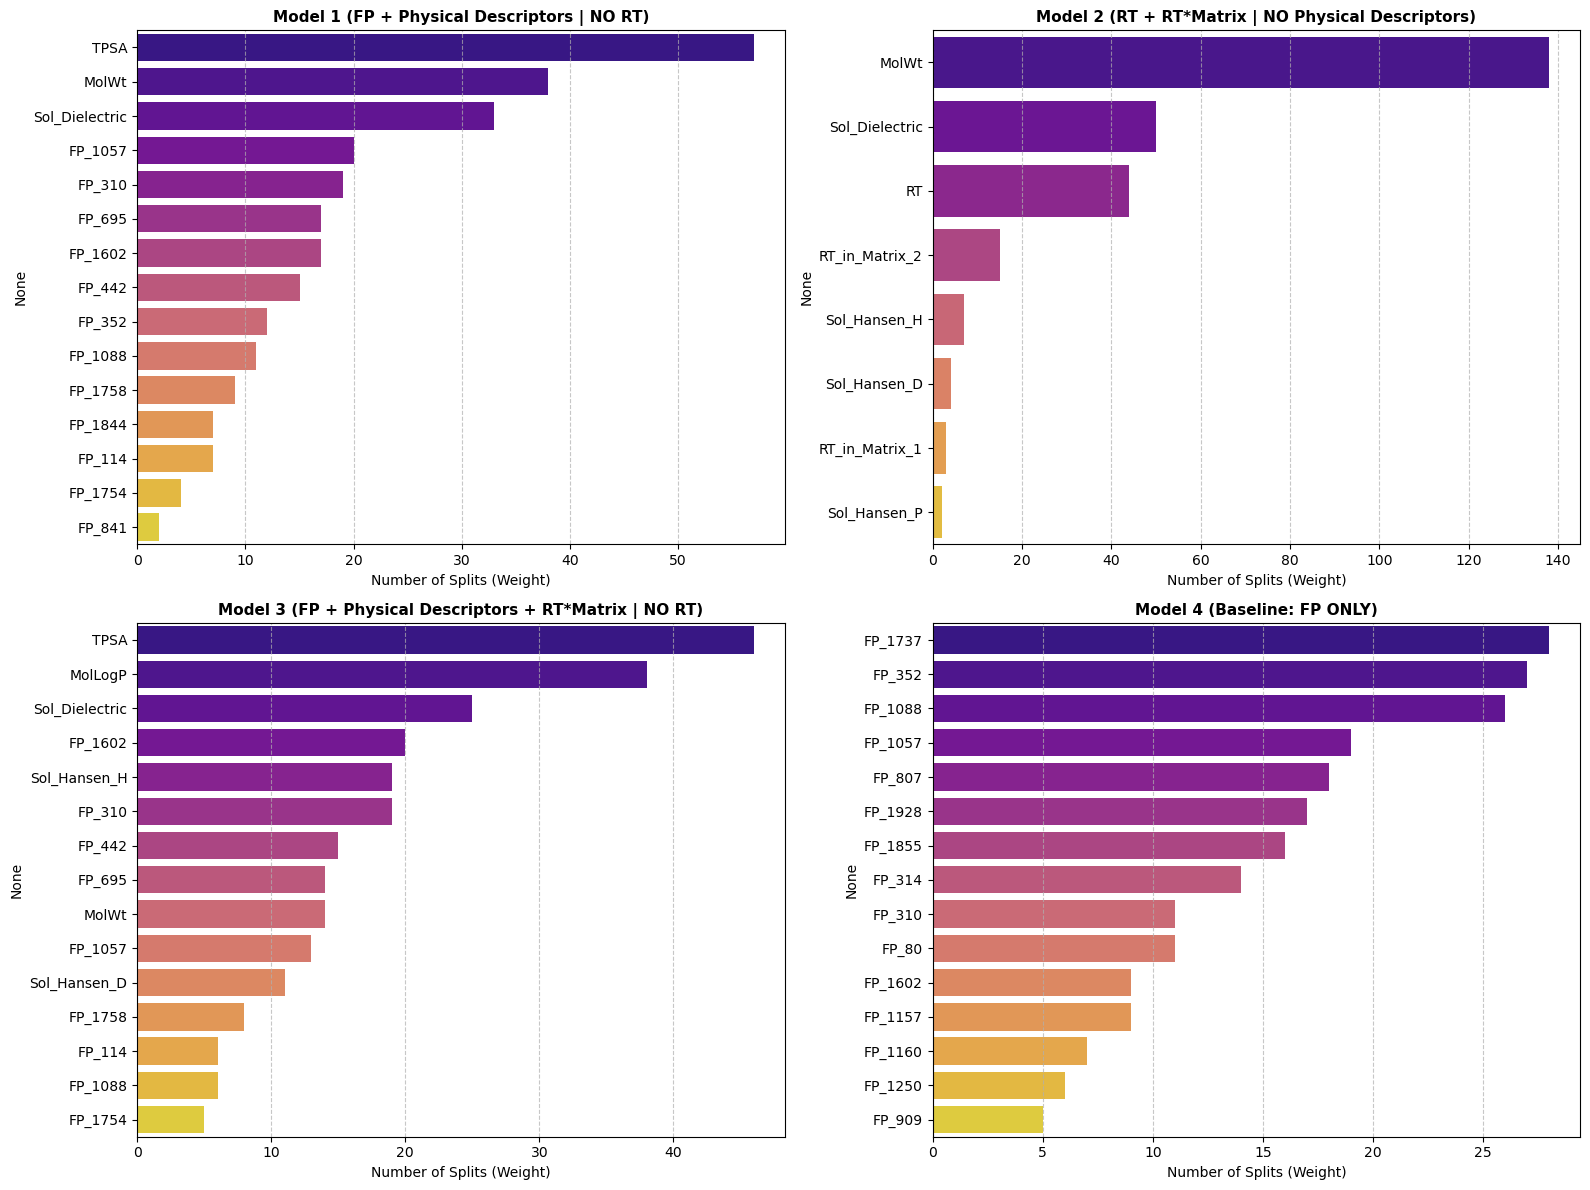

In [77]:
# 1. DEFINE BASE NAME LISTS
num_fp = X_fp.shape[1]
num_mat = X_mat.shape[1]

list_fp = np.array([f"FP_{i}" for i in range(num_fp)])
list_interaction = [f"RT_in_Matrix_{i}" for i in range(num_mat)]
cols_physics = ['MolLogP', 'TPSA', 'MolWt', 'Sol_Dielectric', 'Sol_Hansen_D', 'Sol_Hansen_P', 'Sol_Hansen_H']

# 2. CAREFULLY RECONSTRUCT EXACT FEATURE NAMES PER MODEL
# Model 1: Selector applied to [FPs + Physics]
raw_names_1 = list(list_fp) + cols_physics
selected_names_1 = np.array(raw_names_1)[selector_1.get_support()]

# Model 2: Selector applied to [Global RT + Interaction]
selected_names_2 = ['RT'] + cols_2 + list_interaction

# Model 3: Selector applied ONLY to FPs. Physics and Interactions got a VIP pass!
selected_fps_3 = list(list_fp[selector_3.get_support()])
selected_names_3 = np.array(selected_fps_3 + cols_physics + list_interaction)

# Model 4: Selector applied ONLY to FPs
selected_names_4 = list_fp[selector_4.get_support()]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

plot_top_15_weight(model_1, selected_names_1, "Model 1 (FP + Physical Descriptors | NO RT)", axes[0])
plot_top_15_weight(model_2, selected_names_2, "Model 2 (RT + RT*Matrix | NO Physical Descriptors)", axes[1])
plot_top_15_weight(model_3, selected_names_3, "Model 3 (FP + Physical Descriptors + RT*Matrix | NO RT)", axes[2])
plot_top_15_weight(model_4, selected_names_4, "Model 4 (Baseline: FP ONLY)", axes[3])

plt.tight_layout()
plt.show()

This is a **dummy** baseline, it only includes the MW. We'll use it to compare some models.

In [63]:
y = df_desc['Soluble'].values
X_dummy = df_desc[['MolWt']].values  # Double brackets keep it a 2D array!

# 2. SPLIT THE DATA
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=54)
train_idx, test_idx = next(gss.split(df_desc, y, groups=df_desc['SMILES']))

y_train, y_test = y[train_idx], y[test_idx]
scale_weight = (len(y_train) - sum(y_train)) / sum(y_train)

# 3. SCALE SAFELY (Fit on train, apply to test)
scaler_dummy = StandardScaler()
X_train_dummy = scaler_dummy.fit_transform(X_dummy[train_idx])
X_test_dummy  = scaler_dummy.transform(X_dummy[test_idx])

# 4. TRAIN THE BASELINE
model_dummy = xgboost.XGBClassifier(
    n_estimators=50, learning_rate=0.05, max_depth=4, subsample=0.8,
    colsample_bytree=1.0, gamma=1, min_child_weight=5, reg_lambda=10,
    scale_pos_weight=scale_weight, random_state=69, eval_metric='logloss', n_jobs=-1
)
model_dummy.fit(X_train_dummy, y_train)

# 5. EVALUATE
y_pred_dummy = model_dummy.predict(X_test_dummy)
print(f"Dummy Accuracy:  {accuracy_score(y_test, y_pred_dummy):.4f}")
print(f"Dummy Precision: {precision_score(y_test, y_pred_dummy, zero_division=0):.4f}\n")

Dummy Accuracy:  0.7836
Dummy Precision: 0.9062



**<u><span style="font-size:18px">Standardizing RT</span><u>**

<span style="color:red">**Z-score method**</span>

If you use standard scaling on the entire RT column, you are treating all the machines as if they are the same. Group-wise Z-scoring (look up formula) fixes this by treating each matrix as its own isolated universe. Instead of absolute minutes, every RT is now a measure of relative speed. A Z-score of 0.0 means "exactly average speed for this specific machine." A score of +1.5 means "unusually slow for this specific machine."

In [78]:
print("--- ENGINEER FEATURE: RT Z-SCORE (PER MATRIX) ---")

# 1. Extract the categorical matrix ID (e.g., 0, 1, 2...) from the one-hot array
matrix_ids = np.argmax(X_mat, axis=1)
unique_matrices = np.unique(matrix_ids)

# 2. Initialize our new array for the Z-score RT
X_rt_z = np.zeros_like(X_rt, dtype=float)

# 3. Calculate Z-score PER MATRIX (Fit on train, apply to all)
for m in unique_matrices:
    # Find rows in the TRAINING set that belong to this matrix
    train_mask = (matrix_ids[train_idx] == m)
    rt_train_m = X_rt[train_idx][train_mask]
    
    if len(rt_train_m) > 0:
        mean_m = np.mean(rt_train_m)
        std_m = np.std(rt_train_m)
        
        # Prevent division by zero if a matrix has no variance
        if std_m == 0: 
            std_m = 1.0 
            
        # Find all rows in the FULL dataset that belong to this matrix
        full_mask = (matrix_ids == m)
        
        # Apply the Z-score formula: (Value - Mean) / Std
        X_rt_z[full_mask] = (X_rt[full_mask] - mean_m) / std_m

# 4. Create the TA's new Z-score Interaction Matrix
X_mat_int_z = X_mat * X_rt_z

--- ENGINEER FEATURE: RT Z-SCORE (PER MATRIX) ---


We'll run this on models 2 and 3 exclusively.

In [86]:
print("--- RUNNING Z-SCORE MODELS ---")

# Define our continuous physics columns
cols_phys_all = ['MolLogP', 'TPSA', 'MolWt', 'Sol_Dielectric', 'Sol_Hansen_D', 'Sol_Hansen_P', 'Sol_Hansen_H']
cols_phys_reduced = ['MolWt', 'Sol_Dielectric', 'Sol_Hansen_D', 'Sol_Hansen_P', 'Sol_Hansen_H']

# Scale Physics (Fit on train, transform test) - We DO NOT scale RT here because it's already Z-scored!
scaler_phys_all = StandardScaler()
X_phys_all_train = scaler_phys_all.fit_transform(df_desc[cols_phys_all].values[train_idx])
X_phys_all_test  = scaler_phys_all.transform(df_desc[cols_phys_all].values[test_idx])

scaler_phys_reduced = StandardScaler()
X_phys_red_train = scaler_phys_reduced.fit_transform(df_desc[cols_phys_reduced].values[train_idx])
X_phys_red_test  = scaler_phys_reduced.transform(df_desc[cols_phys_reduced].values[test_idx])

--- RUNNING Z-SCORE MODELS ---


In [87]:
def train_evaluate_variation(X_train_raw, X_test_raw, y_train, y_test, name, is_model_3=False):
    if is_model_3:
        # VIP PASS FOR MODEL 3 (Filter FP, keep the rest)
        num_fp = X_fp.shape[1]
        X_train_fp, X_test_fp = X_train_raw[:, :num_fp], X_test_raw[:, :num_fp]
        X_train_rest, X_test_rest = X_train_raw[:, num_fp:], X_test_raw[:, num_fp:]
        
        selector = SelectKBest(score_func=f_classif, k=200)
        X_train_fp_best = selector.fit_transform(X_train_fp, y_train)
        X_test_fp_best = selector.transform(X_test_fp)
        
        X_train_final = np.hstack((X_train_fp_best, X_train_rest))
        X_test_final = np.hstack((X_test_fp_best, X_test_rest))
    else:
        # MODEL 2 (Filter everything slightly, but we have few features so it keeps most)
        selector = SelectKBest(score_func=f_classif, k=min(15, X_train_raw.shape[1]))
        X_train_final = selector.fit_transform(X_train_raw, y_train)
        X_test_final = selector.transform(X_test_raw)

    model = xgboost.XGBClassifier(
        n_estimators=50, learning_rate=0.05, max_depth=4, subsample=0.8,
        colsample_bytree=1.0, gamma=1, min_child_weight=5, reg_lambda=10, 
        scale_pos_weight=scale_weight, random_state=69, n_jobs=-1
    )
    model.fit(X_train_final, y_train)
    
    y_pred = model.predict(X_test_final)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    
    print(f"{name:.<45} Accuracy: {acc:.4f} | Precision: {prec:.4f}")
    return model, selector

In [88]:
# Model 2a: Physics + Z-RT + One-Hot
X_train_2a_z = np.hstack((X_phys_red_train, X_rt_z[train_idx], X_mat[train_idx]))
X_test_2a_z  = np.hstack((X_phys_red_test, X_rt_z[test_idx], X_mat[test_idx]))

# Model 2b: Physics + Z-RT + Interaction
X_train_2b_z = np.hstack((X_phys_red_train, X_mat_int_z[train_idx]))
X_test_2b_z  = np.hstack((X_phys_red_test, X_mat_int_z[test_idx]))

# Model 3a: FP + Physics + Z-RT + One-Hot
X_train_3a_z = np.hstack((X_fp[train_idx], X_phys_all_train, X_rt_z[train_idx], X_mat[train_idx]))
X_test_3a_z  = np.hstack((X_fp[test_idx], X_phys_all_test, X_rt_z[test_idx], X_mat[test_idx]))

# Model 3b: FP + Physics + Z-RT + Interaction
X_train_3b_z = np.hstack((X_fp[train_idx], X_phys_all_train, X_mat_int_z[train_idx]))
X_test_3b_z  = np.hstack((X_fp[test_idx], X_phys_all_test, X_mat_int_z[test_idx]))

In [89]:
m2a_z, s2a_z = train_evaluate_variation(X_train_2a_z, X_test_2a_z, y_train, y_test, "Model 2a (Z-Score | RT + Matrix ID)")
m2b_z, s2b_z = train_evaluate_variation(X_train_2b_z, X_test_2b_z, y_train, y_test, "Model 2b (Z-Score | Interaction Mat*RT)")
print("-" * 65)
m3a_z, s3a_z = train_evaluate_variation(X_train_3a_z, X_test_3a_z, y_train, y_test, "Model 3a (Z-Score | RT + Matrix ID)", is_model_3=True)
m3b_z, s3b_z = train_evaluate_variation(X_train_3b_z, X_test_3b_z, y_train, y_test, "Model 3b (Z-Score | Interaction Mat*RT)", is_model_3=True)

Model 2a (Z-Score | RT + Matrix ID).......... Accuracy: 0.8327 | Precision: 0.9342
Model 2b (Z-Score | Interaction Mat*RT)...... Accuracy: 0.8052 | Precision: 0.9086
-----------------------------------------------------------------
Model 3a (Z-Score | RT + Matrix ID).......... Accuracy: 0.8245 | Precision: 0.9463
Model 3b (Z-Score | Interaction Mat*RT)...... Accuracy: 0.8208 | Precision: 0.9461


**Features Importance**

In [90]:
# Reconstruct the feature names for our models
names_phys = ['MolLogP', 'TPSA', 'MolWt', 'Sol_Dielectric', 'Sol_Hansen_D', 'Sol_Hansen_P', 'Sol_Hansen_H']
names_phys_reduced = ['MolWt', 'Sol_Dielectric', 'Sol_Hansen_D', 'Sol_Hansen_P', 'Sol_Hansen_H']
names_2a_z_raw = names_phys_reduced + ['RT_Z_Score'] + [f"Matrix_{i}" for i in range(X_mat.shape[1])]
names_2b_z_raw = names_phys_reduced +[f"RT_in_Matrix_{i}" for i in range(X_mat.shape[1])]

# Filter them using the selectors we saved
names_2a_z_selected = np.array(names_2a_z_raw)[s2a_z.get_support()]
names_2b_z_selected = np.array(names_2b_z_raw)[s2b_z.get_support()]

# Create dataframes
imp_2a_z = pd.DataFrame({'Feature': names_2a_z_selected, 'Importance': m2a_z.feature_importances_})
imp_2b_z = pd.DataFrame({'Feature': names_2b_z_selected, 'Importance': m2b_z.feature_importances_})

print(" MODEL 2a (Z-Score | RT + Matrix ID):")
print(imp_2a_z.sort_values(by='Importance', ascending=False).head(5).to_string(index=False))

print("\n MODEL 2b (Z-Score | Interaction Mat*RT):")
print(imp_2b_z.sort_values(by='Importance', ascending=False).head(5).to_string(index=False))

 MODEL 2a (Z-Score | RT + Matrix ID):
       Feature  Importance
  Sol_Hansen_H    0.245282
Sol_Dielectric    0.206881
    RT_Z_Score    0.197961
         MolWt    0.154274
  Sol_Hansen_P    0.075971

 MODEL 2b (Z-Score | Interaction Mat*RT):
       Feature  Importance
Sol_Dielectric    0.308306
         MolWt    0.200336
RT_in_Matrix_5    0.171815
RT_in_Matrix_3    0.132542
RT_in_Matrix_0    0.119349


<span style="color:red">**Linear Scaling**</span>

Forces every single run to fit strictly between 0.0 and 1.0. It tells the AI: "This molecule was the absolute fastest one we saw on this machine (0.0)," or "This was the absolute slowest one (1.0)," or "This was exactly halfway between the fastest and slowest (0.5)." It may be highly sensitive to outliers though.

In [91]:
print("--- ENGINEER FEATURE: RT LINEAR SCALING (PER MATRIX) ---")

# 1. Extract the categorical matrix ID just in case
matrix_ids = np.argmax(X_mat, axis=1)
unique_matrices = np.unique(matrix_ids)

# 2. Initialize our new array for the Linear Scaled RT
X_rt_lin = np.zeros_like(X_rt, dtype=float)

# 3. Calculate Min/Max PER MATRIX (Fit on train ONLY to prevent data leakage!)
for m in unique_matrices:
    train_mask = (matrix_ids[train_idx] == m)
    rt_train_m = X_rt[train_idx][train_mask]
    
    if len(rt_train_m) > 0:
        min_m = np.min(rt_train_m)
        max_m = np.max(rt_train_m)
        range_m = max_m - min_m
        
        # Prevent division by zero if all molecules have the exact same RT
        if range_m == 0: 
            range_m = 1.0 
            
        full_mask = (matrix_ids == m)
        X_rt_lin[full_mask] = (X_rt[full_mask] - min_m) / range_m

# 4. Create the Interaction Matrix for Linear Scaling
X_mat_int_lin = X_mat * X_rt_lin

--- ENGINEER FEATURE: RT LINEAR SCALING (PER MATRIX) ---


In [92]:
print("--- RUNNING LINEAR SCALED MODELS ---")

# --- ASSEMBLE THE ARRAYS ---
# Model 2a: Physics + Lin-RT + One-Hot
X_train_2a_lin = np.hstack((X_phys_red_train, X_rt_lin[train_idx], X_mat[train_idx]))
X_test_2a_lin  = np.hstack((X_phys_red_test, X_rt_lin[test_idx], X_mat[test_idx]))

# Model 2b: Physics + Lin-RT + Interaction
X_train_2b_lin = np.hstack((X_phys_red_train, X_mat_int_lin[train_idx]))
X_test_2b_lin  = np.hstack((X_phys_red_test, X_mat_int_lin[test_idx]))

# Model 3a: FP + Physics + Lin-RT + One-Hot
X_train_3a_lin = np.hstack((X_fp[train_idx], X_phys_all_train, X_rt_lin[train_idx], X_mat[train_idx]))
X_test_3a_lin  = np.hstack((X_fp[test_idx], X_phys_all_test, X_rt_lin[test_idx], X_mat[test_idx]))

# Model 3b: FP + Physics + Lin-RT + Interaction
X_train_3b_lin = np.hstack((X_fp[train_idx], X_phys_all_train, X_mat_int_lin[train_idx]))
X_test_3b_lin  = np.hstack((X_fp[test_idx], X_phys_all_test, X_mat_int_lin[test_idx]))

# --- RUN THEM ---
m2a_lin, s2a_lin = train_evaluate_variation(X_train_2a_lin, X_test_2a_lin, y_train, y_test, "Model 2a (Linear | RT + Matrix ID)")
m2b_lin, s2b_lin = train_evaluate_variation(X_train_2b_lin, X_test_2b_lin, y_train, y_test, "Model 2b (Linear | Interaction Mat*RT)")
print("-" * 65)
m3a_lin, s3a_lin = train_evaluate_variation(X_train_3a_lin, X_test_3a_lin, y_train, y_test, "Model 3a (Linear | RT + Matrix ID)", is_model_3=True)
m3b_lin, s3b_lin = train_evaluate_variation(X_train_3b_lin, X_test_3b_lin, y_train, y_test, "Model 3b (Linear | Interaction Mat*RT)", is_model_3=True)

--- RUNNING LINEAR SCALED MODELS ---
Model 2a (Linear | RT + Matrix ID)........... Accuracy: 0.8364 | Precision: 0.9345
Model 2b (Linear | Interaction Mat*RT)....... Accuracy: 0.8052 | Precision: 0.9086
-----------------------------------------------------------------
Model 3a (Linear | RT + Matrix ID)........... Accuracy: 0.8245 | Precision: 0.9463
Model 3b (Linear | Interaction Mat*RT)....... Accuracy: 0.8208 | Precision: 0.9461


In [ ]:
print("--- LINEAR SCALING FEATURE IMPORTANCES ---")

# Reconstructs the raw column names for our different models
names_phys = ['MolLogP', 'TPSA', 'MolWt', 'Sol_Dielectric', 'Sol_Hansen_D', 'Sol_Hansen_P', 'Sol_Hansen_H']
names_phys_reduced = ['MolWt', 'Sol_Dielectric', 'Sol_Hansen_D', 'Sol_Hansen_P', 'Sol_Hansen_H']
num_fp = X_fp.shape[1]
num_mat = X_mat.shape[1]

list_fp = np.array([f"FP_{i}" for i in range(num_fp)])
list_mat = [f"Matrix_{i}" for i in range(num_mat)]
list_int_lin = [f"RT_in_Matrix_{i}_Lin" for i in range(num_mat)]

# Gets the exact names for Model 2
names_2a_raw = names_phys_reduced + ['RT_Lin_Score'] + list_mat
names_2a_lin = np.array(names_2a_raw)[s2a_lin.get_support()]

names_2b_raw = names_phys_reduced + list_int_lin
names_2b_lin = np.array(names_2b_raw)[s2b_lin.get_support()]

# Gets the exact names for Model 3
selected_fps_3a = list_fp[s3a_lin.get_support()]
names_3a_lin = list(selected_fps_3a) + names_phys + ['RT_Lin_Score'] + list_mat

selected_fps_3b = list_fp[s3b_lin.get_support()]
names_3b_lin = list(selected_fps_3b) + names_phys + list_int_lin

# Creates the four different DataFrames
imp_2a_lin = pd.DataFrame({'Feature': names_2a_lin, 'Importance': m2a_lin.feature_importances_})
imp_2b_lin = pd.DataFrame({'Feature': names_2b_lin, 'Importance': m2b_lin.feature_importances_})
imp_3a_lin = pd.DataFrame({'Feature': names_3a_lin, 'Importance': m3a_lin.feature_importances_})
imp_3b_lin = pd.DataFrame({'Feature': names_3b_lin, 'Importance': m3b_lin.feature_importances_})

# Prints the top 10 features for each
print("\n MODEL 2a (Linear | RT + Mat):")
print(imp_2a_lin.sort_values(by='Importance', ascending=False).head(10).to_string(index=False))

print("\n MODEL 2b Linear | Interaction Mat*RT):")
print(imp_2b_lin.sort_values(by='Importance', ascending=False).head(10).to_string(index=False))

print("\n MODEL 3a (Linear | RT + Mat):")
# Hide the fingerprints just for the printout so we can see the physics clearly
rt_mat_phys_3a = imp_3a_lin[~imp_3a_lin['Feature'].str.contains('FP_')].copy()
print(rt_mat_phys_3a.sort_values(by='Importance', ascending=False).head(10).to_string(index=False))

print("\n MODEL 3b (Linear | Interaction Mat*RT):")
rt_mat_phys_3b = imp_3b_lin[~imp_3b_lin['Feature'].str.contains('FP_')].copy()
print(rt_mat_phys_3b.sort_values(by='Importance', ascending=False).head(10).to_string(index=False))

--- LINEAR SCALING FEATURE IMPORTANCES ---

 MODEL 2a (Linear | RT + Mat):
       Feature  Importance
  Sol_Hansen_H    0.240798
Sol_Dielectric    0.214748
  RT_Lin_Score    0.176774
         MolWt    0.155849
  Sol_Hansen_P    0.098974
  Sol_Hansen_D    0.052602
      Matrix_2    0.030678
      Matrix_1    0.029577
      Matrix_0    0.000000
      Matrix_3    0.000000

 MODEL 2b Linear | Interaction Mat*RT):
           Feature  Importance
    Sol_Dielectric    0.528279
             MolWt    0.349025
      Sol_Hansen_D    0.071836
      Sol_Hansen_P    0.050860
      Sol_Hansen_H    0.000000
RT_in_Matrix_0_Lin    0.000000
RT_in_Matrix_1_Lin    0.000000
RT_in_Matrix_2_Lin    0.000000
RT_in_Matrix_3_Lin    0.000000
RT_in_Matrix_4_Lin    0.000000

 MODEL 3a (Linear | RT + Mat):
       Feature  Importance
          TPSA    0.220816
         MolWt    0.083504
       MolLogP    0.050988
Sol_Dielectric    0.040931
  Sol_Hansen_H    0.022988
  Sol_Hansen_D    0.021525
  RT_Lin_Score    0.01168

<span style="color:red">**Percentile Rank**</span>

Instead of looking at the actual minutes, it just looks at the order of the molecules. The fastest molecule is the 0th percentile (0.0). The median molecule is the 50th percentile (0.50). The absolute slowest molecule is the 100th percentile (1.0).

In [95]:
print("--- ENGINEER FEATURE: RT PERCENTILE RANK (PER MATRIX) ---")

X_rt_pct = np.zeros_like(X_rt, dtype=float)

# Calculate Percentile Rank PER MATRIX (Relative to Training Data)
for m in unique_matrices:
    train_mask = (matrix_ids[train_idx] == m)
    rt_train_m = X_rt[train_idx][train_mask].flatten()
    
    if len(rt_train_m) > 0:
        full_mask = (matrix_ids == m)
        rt_full_m = X_rt[full_mask].flatten()
        
        # Calculate the percentile of every row relative to the training distribution
        # We divide by 100 to scale it between 0.0 and 1.0
        pct_scores = [stats.percentileofscore(rt_train_m, val, kind='rank') / 100.0 for val in rt_full_m]
        
        X_rt_pct[full_mask, 0] = pct_scores

# Create the Interaction Matrix for Percentile
X_mat_int_pct = X_mat * X_rt_pct

--- ENGINEER FEATURE: RT PERCENTILE RANK (PER MATRIX) ---


In [96]:
print("--- RUNNING PERCENTILE RANK MODELS ---")

# Assemble the arrays
# Model 2: Physics + Pct-RT + One-Hot/Interaction
X_train_2a_pct = np.hstack((X_phys_red_train, X_rt_pct[train_idx], X_mat[train_idx]))
X_test_2a_pct  = np.hstack((X_phys_red_test, X_rt_pct[test_idx], X_mat[test_idx]))

X_train_2b_pct = np.hstack((X_phys_red_train, X_mat_int_pct[train_idx]))
X_test_2b_pct  = np.hstack((X_phys_red_test, X_mat_int_pct[test_idx]))

# Model 3: FP + Physics + Pct-RT + One-Hot/Interaction
X_train_3a_pct = np.hstack((X_fp[train_idx], X_phys_all_train, X_rt_pct[train_idx], X_mat[train_idx]))
X_test_3a_pct  = np.hstack((X_fp[test_idx], X_phys_all_test, X_rt_pct[test_idx], X_mat[test_idx]))

X_train_3b_pct = np.hstack((X_fp[train_idx], X_phys_all_train, X_mat_int_pct[train_idx]))
X_test_3b_pct  = np.hstack((X_fp[test_idx], X_phys_all_test, X_mat_int_pct[test_idx]))

--- RUNNING PERCENTILE RANK MODELS ---


In [97]:
# Run them
m2a_pct, s2a_pct = train_evaluate_variation(X_train_2a_pct, X_test_2a_pct, y_train, y_test, "Model 2a (Percentile | Separate RT & Mat)")
m2b_pct, s2b_pct = train_evaluate_variation(X_train_2b_pct, X_test_2b_pct, y_train, y_test, "Model 2b (Percentile | Interaction Mat*RT)")
print("-" * 65)
m3a_pct, s3a_pct = train_evaluate_variation(X_train_3a_pct, X_test_3a_pct, y_train, y_test, "Model 3a (Percentile | Separate RT & Mat)", is_model_3=True)
m3b_pct, s3b_pct = train_evaluate_variation(X_train_3b_pct, X_test_3b_pct, y_train, y_test, "Model 3b (Percentile | Interaction Mat*RT)", is_model_3=True)

Model 2a (Percentile | Separate RT & Mat).... Accuracy: 0.8238 | Precision: 0.9342
Model 2b (Percentile | Interaction Mat*RT)... Accuracy: 0.8052 | Precision: 0.9086
-----------------------------------------------------------------
Model 3a (Percentile | Separate RT & Mat).... Accuracy: 0.8245 | Precision: 0.9463
Model 3b (Percentile | Interaction Mat*RT)... Accuracy: 0.8208 | Precision: 0.9461


It's basically the same results than with z-scoring. Because Z-Score, Min/Max, and Percentile Rank all keep the molecules in the exact same order (from fastest to slowest), XGBoost draws the exact same lines, builds the exact same trees, and gets the exact same accuracy. A slight change is observed because Z-scoring and Percentile Ranking align the different matrices slightly differently when you squish them back into a single column. That tiny 0.0008 difference means literally one or two molecules out of your entire dataset fell on the wrong side of a tree branch.

In [99]:
# 1. Reconstruct the raw name components
names_phys_all = ['MolLogP', 'TPSA', 'MolWt', 'Sol_Dielectric', 'Sol_Hansen_D', 'Sol_Hansen_P', 'Sol_Hansen_H']
names_phys_red = ['MolWt', 'Sol_Dielectric', 'Sol_Hansen_D', 'Sol_Hansen_P', 'Sol_Hansen_H']

num_fp = X_fp.shape[1]
num_mat = X_mat.shape[1]

list_fp = np.array([f"FP_{i}" for i in range(num_fp)])
list_mat = [f"Matrix_{i}" for i in range(num_mat)]
list_int_pct = [f"RT_in_Matrix_{i}_Pct" for i in range(num_mat)]

# 2. Get the exact names for Model 2 
names_2a_raw = names_phys_red + ['RT_Pct_Score'] + list_mat
names_2a_pct = np.array(names_2a_raw)[s2a_pct.get_support()]

# FIX: Removed the floating 'RT_Pct_Score' that wasn't in the training array!
names_2b_raw = names_phys_red + list_int_pct
names_2b_pct = np.array(names_2b_raw)[s2b_pct.get_support()]

# 3. Get the exact names for Model 3 
selected_fps_3a = list_fp[s3a_pct.get_support()]
names_3a_pct = list(selected_fps_3a) + names_phys_all + ['RT_Pct_Score'] + list_mat

# FIX: Removed the floating 'RT_Pct_Score' that wasn't in the training array!
selected_fps_3b = list_fp[s3b_pct.get_support()]
names_3b_pct = list(selected_fps_3b) + names_phys_all + list_int_pct

# 4. Create the DataFrames
imp_2a_pct = pd.DataFrame({'Feature': names_2a_pct, 'Importance': m2a_pct.feature_importances_})
imp_2b_pct = pd.DataFrame({'Feature': names_2b_pct, 'Importance': m2b_pct.feature_importances_})
imp_3a_pct = pd.DataFrame({'Feature': names_3a_pct, 'Importance': m3a_pct.feature_importances_})
imp_3b_pct = pd.DataFrame({'Feature': names_3b_pct, 'Importance': m3b_pct.feature_importances_})
# 5. Print the Top 10 for each!
print("\n MODEL 2a (Percentile RT + Separate Matrix):")
print(imp_2a_pct.sort_values(by='Importance', ascending=False).head(10).to_string(index=False))

print("\n MODEL 2b (Percentile RT + Interaction):")
print(imp_2b_pct.sort_values(by='Importance', ascending=False).head(10).to_string(index=False))

print("\n MODEL 3a (FP + Percentile RT + Separate Matrix) - Lab/Physics Only:")
# Hide the fingerprints just for the printout so we can see the physics clearly
rt_mat_phys_3a = imp_3a_pct[~imp_3a_pct['Feature'].str.contains('FP_')].copy()
print(rt_mat_phys_3a.sort_values(by='Importance', ascending=False).head(10).to_string(index=False))

print("\n MODEL 3b (FP + Percentile RT + Interaction) - Lab/Physics Only:")
rt_mat_phys_3b = imp_3b_pct[~imp_3b_pct['Feature'].str.contains('FP_')].copy()
print(rt_mat_phys_3b.sort_values(by='Importance', ascending=False).head(10).to_string(index=False))


 MODEL 2a (Percentile RT + Separate Matrix):
       Feature  Importance
  Sol_Hansen_H    0.276850
Sol_Dielectric    0.201845
  RT_Pct_Score    0.181702
         MolWt    0.173523
  Sol_Hansen_D    0.045951
      Matrix_2    0.044244
      Matrix_1    0.039121
  Sol_Hansen_P    0.036765
      Matrix_0    0.000000
      Matrix_3    0.000000

 MODEL 2b (Percentile RT + Interaction):
           Feature  Importance
    Sol_Dielectric    0.528279
             MolWt    0.349025
      Sol_Hansen_D    0.071836
      Sol_Hansen_P    0.050860
      Sol_Hansen_H    0.000000
RT_in_Matrix_0_Pct    0.000000
RT_in_Matrix_1_Pct    0.000000
RT_in_Matrix_2_Pct    0.000000
RT_in_Matrix_3_Pct    0.000000
RT_in_Matrix_4_Pct    0.000000

 MODEL 3a (FP + Percentile RT + Separate Matrix) - Lab/Physics Only:
       Feature  Importance
          TPSA    0.230380
         MolWt    0.087007
       MolLogP    0.053137
Sol_Dielectric    0.042696
  Sol_Hansen_H    0.024000
  Sol_Hansen_D    0.022470
  RT_Pct_Score 

**<u><span style="font-size:18px">Adding Matrix IDs</span><u>**

The matrix ID have been part of our dataframe since the beginning, one-hot coded in. But they actually represent a complex set of column conditions defined as a vector containing differebt values (not just 0s and 1s). As seen before, the model has a hard time to fully integraste these matrices, even though it tends to use 2 or 3 sometimes. Let's see how it goes, the matrix ID vectors were obtained in the *matrixIDs.xlsx* file.

Given the results on **Standardizing RT**, I'm not going to use them. I'll first leave RT and Matrix ID separate.

In [6]:
# Creating the new dataframe, the first steps can be kept
raw_df = pd.read_excel('/Users/arthurbenard/Project 1B/data/Fichier final (RT+sol)_with_smiles.xlsx')
raw_df['SMILES'] = raw_df['solute_smiles'].astype(str).str.strip()

sol_matrix_dirty= pd.read_excel('/Users/arthurbenard/Project 1B/data/Master_Solubility_Matrix.xlsx')
sol_matrix_dirty['SMILES'] = sol_matrix_dirty['solute_smiles'].astype(str).str.strip()

sol_matrix = sol_matrix_dirty.drop_duplicates(subset=['SMILES'], keep='first')

# Deleting rows with signals = 0
raw_df = raw_df[raw_df['RT'] != 0].copy()

# Merges the predicted solubilities with the future df like before
all_dfs_final = []

for sol_name in NMR_SOLVENTS.keys():
    target_col = f"predicted_logS_{sol_name}"
    
    if target_col in sol_matrix.columns:
        temp_raw = raw_df[['SMILES', 'RT', 'Matrix ID Name']].copy()
        temp_sol = sol_matrix[['SMILES', target_col]].copy()
        temp = temp_raw.merge(temp_sol, on='SMILES', how='inner')
        
        if len(temp) > 0:
            temp = temp.rename(columns={target_col: 'logS'})
            temp['Solvent_Name'] = sol_name
            temp['Soluble'] = (temp['logS'] >= -2).astype(int)
            all_dfs_final.append(temp)
            print(f" Added {sol_name}: {len(temp)} rows")
        else:
            print(f" {sol_name}: Merge resulted in 0 rows.")
    else:
        print(f" {target_col} not found in sol_matrix columns.")


# Combines everything
df_desc = pd.concat(all_dfs_final, ignore_index=True)


 Added MeOH: 895 rows
 Added ACN: 895 rows
 Added DMSO: 895 rows
 Added DCM: 895 rows
 Added CHCl3: 895 rows


What actually is different from before.

In [7]:
# Removes 'matrix ID ' in the original column names (was a problem)
df_desc['Matrix ID Name'] = df_desc['Matrix ID Name'].str.replace('matrix ID ', '', regex=False).str.strip()

# The first step is to rename the columns in the given file
matrix_vectors_df = pd.read_excel('/Users/arthurbenard/Project 1B/data/matrixIDs.xlsx')
matrix_vectors_df = matrix_vectors_df.rename(columns={'MatrixID': 'Matrix ID Name'})

# Looks at all the column headers in the file. If the header starts with the letter 'M', adds it to my list.  That way, if new components are 
# given the code adapts easily.
m_cols = [col for col in matrix_vectors_df.columns if col.startswith('M') and col != 'Matrix ID Name']

# Creating a dictionnary, .iterrows() function tells Python to read file line by line and creates key/value pair by grabbing numbers inside m_cols 
# then converting them to decimals then wrapping them in a single array.
matrix_vector_dict = {
    row['Matrix ID Name']: row[m_cols].values.astype(float)
    for _, row in matrix_vectors_df.iterrows()
}

# .map() instantly looks at 'Matrix ID Name' for all rows and attributes the specific array
df_desc['Matrix_Packed_Array'] = df_desc['Matrix ID Name'].map(matrix_vector_dict)

In [8]:
print("1/3 Mapping Solvent Physics...")
unique_solvents = pd.DataFrame({'Solvent_Name': df_desc['Solvent_Name'].unique()})
unique_solvents[['Sol_Dielectric', 'Sol_Hansen_D', 'Sol_Hansen_P', 'Sol_Hansen_H']] = unique_solvents['Solvent_Name'].apply(extract_solvent_physics).apply(pd.Series)
df_desc = df_desc.merge(unique_solvents, on='Solvent_Name', how='left')

1/3 Mapping Solvent Physics...


In [9]:
print("2/3 Mapping SMILES Descriptors...")
unique_smiles = pd.DataFrame({'SMILES': df_desc['SMILES'].unique()})
unique_smiles[['MolLogP', 'TPSA', 'MolWt', 'NumHDonors', 'NumHAcceptors']] = unique_smiles['SMILES'].apply(calculate_descriptors).apply(pd.Series)
df_desc = df_desc.merge(unique_smiles, on='SMILES', how='left')

2/3 Mapping SMILES Descriptors...


In [10]:
print("3/3 Generating Structural Fingerprints...")
fp_dict = {smi: smiles_to_fingerprint(smi) for smi in df_desc['SMILES'].unique()}
df_desc['Sample Fingerprint'] = df_desc['SMILES'].map(fp_dict)

print(f"\n DATASET GENERATED SUCCESSFULLY")

3/3 Generating Structural Fingerprints...


[16:13:13] DEPRECATION WARNING: please use MorganGenerator
[16:13:13] DEPRECATION WARNING: please use MorganGenerator
[16:13:13] DEPRECATION WARNING: please use MorganGenerator
[16:13:13] DEPRECATION WARNING: please use MorganGenerator
[16:13:13] DEPRECATION WARNING: please use MorganGenerator
[16:13:13] DEPRECATION WARNING: please use MorganGenerator
[16:13:13] DEPRECATION WARNING: please use MorganGenerator
[16:13:13] DEPRECATION WARNING: please use MorganGenerator
[16:13:13] DEPRECATION WARNING: please use MorganGenerator
[16:13:13] DEPRECATION WARNING: please use MorganGenerator
[16:13:13] DEPRECATION WARNING: please use MorganGenerator
[16:13:13] DEPRECATION WARNING: please use MorganGenerator
[16:13:13] DEPRECATION WARNING: please use MorganGenerator
[16:13:13] DEPRECATION WARNING: please use MorganGenerator
[16:13:13] DEPRECATION WARNING: please use MorganGenerator
[16:13:13] DEPRECATION WARNING: please use MorganGenerator
[16:13:13] DEPRECATION WARNING: please use MorganGenerat


 DATASET GENERATED SUCCESSFULLY


[16:13:13] DEPRECATION WARNING: please use MorganGenerator
[16:13:13] DEPRECATION WARNING: please use MorganGenerator
[16:13:13] DEPRECATION WARNING: please use MorganGenerator
[16:13:13] DEPRECATION WARNING: please use MorganGenerator
[16:13:13] DEPRECATION WARNING: please use MorganGenerator
[16:13:13] DEPRECATION WARNING: please use MorganGenerator
[16:13:13] DEPRECATION WARNING: please use MorganGenerator
[16:13:13] DEPRECATION WARNING: please use MorganGenerator
[16:13:13] DEPRECATION WARNING: please use MorganGenerator
[16:13:13] DEPRECATION WARNING: please use MorganGenerator
[16:13:13] DEPRECATION WARNING: please use MorganGenerator
[16:13:13] DEPRECATION WARNING: please use MorganGenerator
[16:13:13] DEPRECATION WARNING: please use MorganGenerator
[16:13:13] DEPRECATION WARNING: please use MorganGenerator
[16:13:13] DEPRECATION WARNING: please use MorganGenerator
[16:13:13] DEPRECATION WARNING: please use MorganGenerator
[16:13:13] DEPRECATION WARNING: please use MorganGenerat

The dataframe has been succesfully generated, next step is to test out its performance. We're gonna train different models like before with the same characteristics as Models A,B,C and D.

**<u><span style="font-size:18px">Testing out different models (E,F,G)</span><u>**

**Creating Model E**

This model is just like model B, it will not train on Fingerprints and Physical Descriptors but only RT and Matrix IDs.

In [11]:
# The target
y = df_desc['Soluble'].values

# Extracting global arrays, stacking them into clean 2D grids
X_fp = np.vstack(df_desc['Sample Fingerprint'].values)
X_mat = np.vstack(df_desc['Matrix_Packed_Array'].values)
X_rt = df_desc[['RT']].values 

# Splitting, ensures ALL models see the exact same train/test rows
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=54)
train_idx, test_idx = next(gss.split(df_desc, y, groups=df_desc['SMILES']))

y_train, y_test = y[train_idx], y[test_idx]

# Calculates a penalty weight
scale_weight = (len(y_train) - sum(y_train)) / sum(y_train)

groups_train = df_desc.iloc[train_idx]['SMILES']

In [12]:
cols_E = ['MolWt', 'Sol_Dielectric', 'Sol_Hansen_D', 'Sol_Hansen_P', 'Sol_Hansen_H']

# Combine RT with the other continuous variables for scaling
X_cont_E = np.hstack((X_rt, df_desc[cols_E].values))
X_train_E_best = np.hstack((X_cont_E[train_idx], X_mat[train_idx]))

X_test_E_best = np.hstack((X_cont_E[test_idx], X_mat[test_idx]))

model_E = xgboost.XGBClassifier(n_estimators=50, learning_rate=0.05, max_depth=4, subsample=0.8,
    colsample_bytree=1.0, gamma=1, min_child_weight=5, reg_lambda=10, scale_pos_weight=scale_weight, random_state=69, n_jobs=-1)
model_E.fit(X_train_E_best, y_train)

y_pred_E = model_E.predict(X_test_E_best)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_E):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_E, zero_division=0):.4f}\n")

Accuracy:  0.8335
Precision: 0.9342



In [13]:
list_matrix_vectors = [f"Matrix_Vector_M{i+1}" for i in range(X_mat.shape[1])]

selected_names_E = ['RT'] + cols_E + list_matrix_vectors

imp_E = pd.DataFrame({'Feature': selected_names_E, 'Importance': model_E.feature_importances_})

print(" MODEL E FEATURE IMPORTANCES:")
print(imp_E.sort_values(by='Importance', ascending=False).to_string(index=False))

 MODEL E FEATURE IMPORTANCES:
          Feature  Importance
     Sol_Hansen_H    0.201593
   Sol_Dielectric    0.184393
               RT    0.170617
            MolWt    0.136608
     Sol_Hansen_P    0.055768
 Matrix_Vector_M3    0.046674
     Sol_Hansen_D    0.046473
Matrix_Vector_M10    0.035664
 Matrix_Vector_M2    0.035136
 Matrix_Vector_M9    0.033041
 Matrix_Vector_M4    0.030309
 Matrix_Vector_M6    0.023722
 Matrix_Vector_M1    0.000000
 Matrix_Vector_M5    0.000000
 Matrix_Vector_M8    0.000000
 Matrix_Vector_M7    0.000000


**Creating Model F**

Model F ressembles model C but has the Matrix IDs included, it trains on everything.

In [16]:
cols_F = ['MolLogP', 'TPSA', 'MolWt', 'Sol_Dielectric', 'Sol_Hansen_D', 'Sol_Hansen_P', 'Sol_Hansen_H']

# Filters **ONLY** the FP (Trim 2048 down to 200)
selector_F = SelectKBest(score_func=f_classif, k=200)
X_train_fp_best = selector_F.fit_transform(X_fp[train_idx], y_train)
X_test_fp_best = selector_F.transform(X_fp[test_idx])

# Same splitting used as before for model E

# Glues everything together (Best FPs + VIP Physics + VIP Interactions)
X_train_F_best = np.hstack((X_train_fp_best, X_rt[train_idx], df_desc[cols_F].values[train_idx], X_mat[train_idx]))
X_test_F_best  = np.hstack((X_test_fp_best, X_rt[test_idx], df_desc[cols_F].values[test_idx], X_mat[test_idx]))

model_F = xgboost.XGBClassifier(n_estimators=50, learning_rate=0.05, max_depth=4, subsample=0.8,
    colsample_bytree=1.0, gamma=1, min_child_weight=5, reg_lambda=10, scale_pos_weight=scale_weight, random_state=69, n_jobs=-1)
model_F.fit(X_train_F_best, y_train)

y_pred_F = model_F.predict(X_test_F_best)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_F):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_F, zero_division=0):.4f}\n")


Accuracy:  0.8245
Precision: 0.9463



In [17]:
list_fp = np.array([f"FP_{i}" for i in range(X_fp.shape[1])])
selected_fps_F = list(list_fp[selector_F.get_support()])
list_matrix_vectors = [f"Matrix_Vector_M{i+1}" for i in range(X_mat.shape[1])]

selected_names_F = selected_fps_F + ['RT'] + cols_F + list_matrix_vectors

imp_F = pd.DataFrame({'Feature': selected_names_F, 'Importance': model_F.feature_importances_})
print("MODEL F FEATURE IMPORTANCES:")
# Hide the fingerprints just for the printout so we can see the physics clearly
rt_mat_phys_F = imp_F[~imp_F['Feature'].str.contains('FP_')].copy()
print(rt_mat_phys_F.sort_values(by='Importance', ascending=False).to_string(index=False))

MODEL F FEATURE IMPORTANCES:
          Feature  Importance
             TPSA    0.220690
            MolWt    0.083447
          MolLogP    0.050906
   Sol_Dielectric    0.040892
     Sol_Hansen_H    0.022973
     Sol_Hansen_D    0.021516
               RT    0.012322
     Sol_Hansen_P    0.000000
 Matrix_Vector_M1    0.000000
 Matrix_Vector_M2    0.000000
 Matrix_Vector_M3    0.000000
 Matrix_Vector_M4    0.000000
 Matrix_Vector_M5    0.000000
 Matrix_Vector_M6    0.000000
 Matrix_Vector_M7    0.000000
 Matrix_Vector_M8    0.000000
 Matrix_Vector_M9    0.000000
Matrix_Vector_M10    0.000000


**<u><span style="font-size:18px">Learning Curves of Models E,F </span><u>**

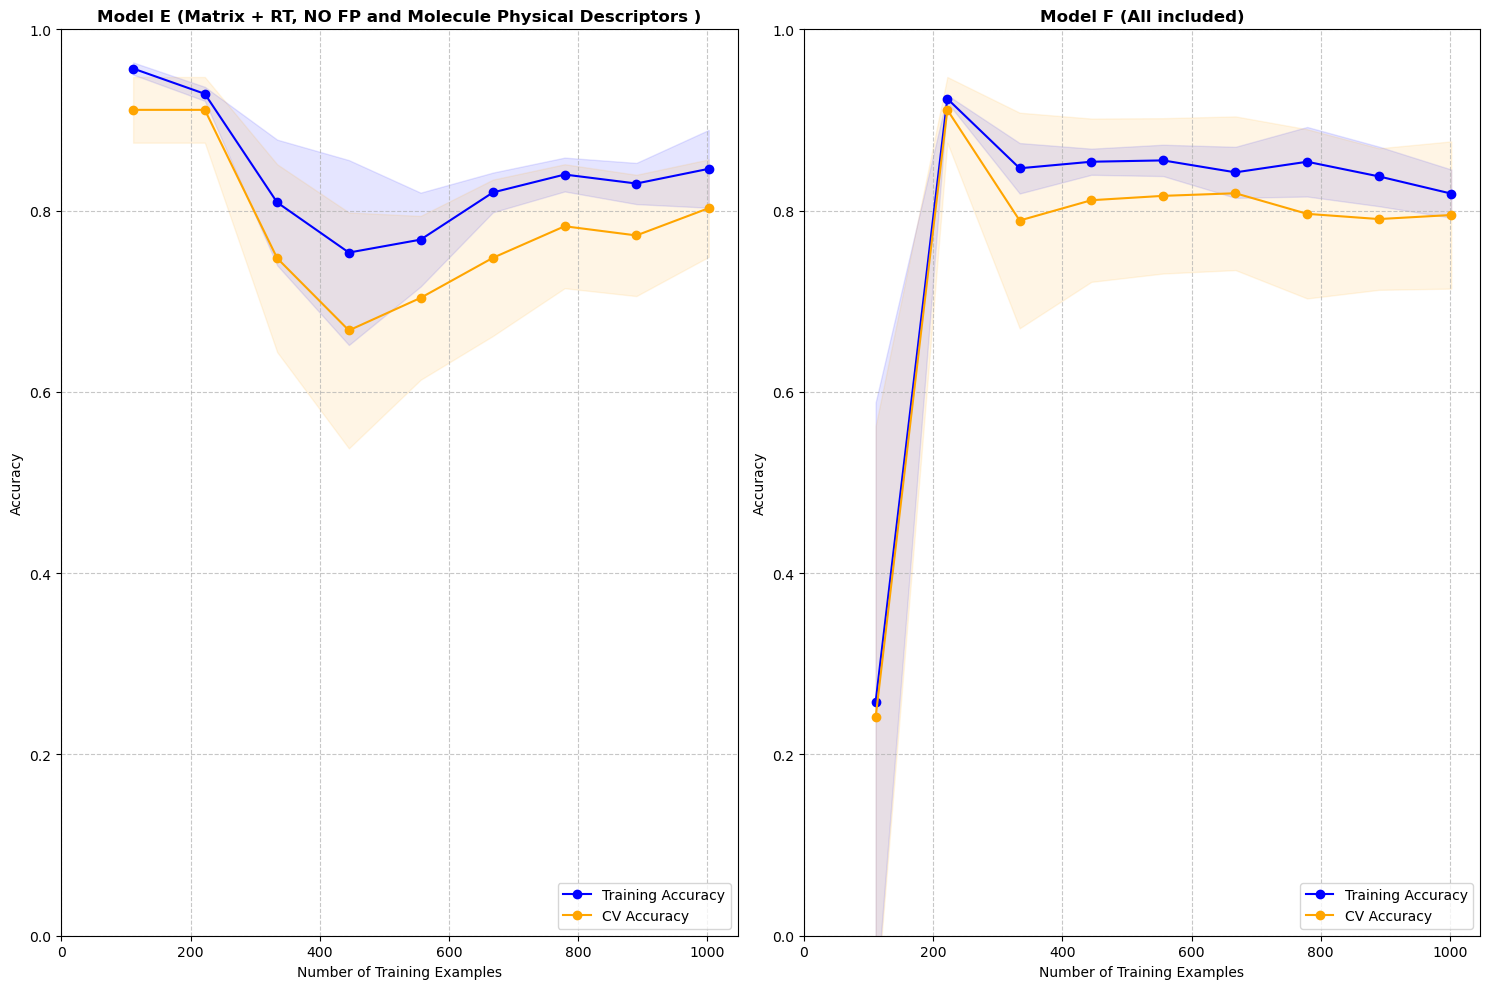

In [47]:
fig, axes = plt.subplots(1,2, figsize=(15, 10))
axes = axes.flatten()

plot_learning_curve(model_E, X_train_E_best, y_train, groups_train, "Model E (Matrix + RT, NO FP and Molecule Physical Descriptors )", axes[0])
plot_learning_curve(model_F, X_train_F_best, y_train, groups_train, "Model F (All included)", axes[1])

plt.tight_layout()
plt.show()

**<u><span style="font-size:18px">Training Data Experiment with Matrix ID</span><u>**

The goal here is to evaluate how well this model (E) would work in the case where a matrix ID is taken out. Two cases will be observed: one where on matrix is taken of the training data and testing data, and another where it is only removed from the training but introduced back in the testing. To do that first part, we unfortunately have to rewrite the training and shuffling. To make it easier we'll call it model G.

**Creating Model G**

In [14]:
# Removing a specific Matrix ID, e.g. PFP 1
df_exp = df_desc[df_desc['Matrix ID Name'] != 'PFP 1'].copy()

# Resetting index to avoid any problems
df_exp = df_exp.reset_index(drop=True)

# Restarting extraction and shuffling like before
y_exp = df_exp['Soluble'].values
X_mat_exp = np.vstack(df_exp['Matrix_Packed_Array'].values)
X_rt_exp = df_exp[['RT']].values

gss_exp = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=54)
train_idx_exp, test_idx_exp = next(gss_exp.split(df_exp, y_exp, groups=df_exp['SMILES']))

y_train_exp, y_test_exp = y_exp[train_idx_exp], y_exp[test_idx_exp]
scale_weight_exp = (len(y_train_exp) - sum(y_train_exp)) / sum(y_train_exp)

In [15]:
cols_G = ['MolWt', 'Sol_Dielectric', 'Sol_Hansen_D', 'Sol_Hansen_P', 'Sol_Hansen_H']

# Combine RT with the other continuous variables for scaling
X_cont_G = np.hstack((X_rt_exp, df_exp[cols_G].values))
X_train_G_best = np.hstack((X_cont_G[train_idx_exp], X_mat_exp[train_idx_exp]))

X_test_G_best = np.hstack((X_cont_G[test_idx_exp], X_mat_exp[test_idx_exp]))

model_G = xgboost.XGBClassifier(n_estimators=50, learning_rate=0.05, max_depth=4, subsample=0.8,
    colsample_bytree=1.0, gamma=1, min_child_weight=5, reg_lambda=10, scale_pos_weight=scale_weight_exp, random_state=69, n_jobs=-1)
model_G.fit(X_train_G_best, y_train_exp)

y_pred_G = model_G.predict(X_test_G_best)
print(f"Accuracy:  {accuracy_score(y_test_exp, y_pred_G):.4f}")
print(f"Precision: {precision_score(y_test_exp, y_pred_G, zero_division=0):.4f}\n")

Accuracy:  0.7284
Precision: 0.9290



In [16]:
list_matrix_vectors = [f"Matrix_Vector_M{i+1}" for i in range(X_mat.shape[1])]

selected_names_G = ['RT'] + cols_G + list_matrix_vectors

imp_G = pd.DataFrame({'Feature': selected_names_G, 'Importance': model_G.feature_importances_})

print(" MODEL G FEATURE IMPORTANCES:")
print(imp_G.sort_values(by='Importance', ascending=False).to_string(index=False))

 MODEL G FEATURE IMPORTANCES:
          Feature  Importance
               RT    0.289087
            MolWt    0.207667
     Sol_Hansen_H    0.168514
   Sol_Dielectric    0.160024
 Matrix_Vector_M2    0.061756
     Sol_Hansen_D    0.061113
 Matrix_Vector_M3    0.051840
     Sol_Hansen_P    0.000000
 Matrix_Vector_M1    0.000000
 Matrix_Vector_M4    0.000000
 Matrix_Vector_M5    0.000000
 Matrix_Vector_M6    0.000000
 Matrix_Vector_M7    0.000000
 Matrix_Vector_M8    0.000000
 Matrix_Vector_M9    0.000000
Matrix_Vector_M10    0.000000


Had the idea to run it in a loop to see if some columns detained more information than others.

In [14]:
train_matrices = df_desc.iloc[train_idx]['Matrix ID Name'].values
test_matrices = df_desc.iloc[test_idx]['Matrix ID Name'].values

selected_matrix_E = ['Bluebird 1', 'PFP 1', 'PolarTec 1', 'RP18 1', 'RP 18 2', 'Sphinx 1', 'Sphinx 2']

df_ablation_results = run_matrix_ablation(
    model_E, 
    X_train_E_best, 
    X_test_E_best, 
    y_train, 
    y_test, 
    train_matrices,    
    test_matrices,
    selected_matrix_E
)

print(" ABLATION STUDY RESULTS:")
print(df_ablation_results.to_string(index=False))

Running Matrix Ablation Study

 ABLATION STUDY RESULTS:
 Dropped_Matrix  Accuracy  Precision  Acc_Change
          PFP 1  0.786842   0.945790   -0.046615
       Sphinx 2  0.819574   0.935484   -0.013883
         RP18 1  0.822026   0.939525   -0.011431
       Sphinx 1  0.823111   0.940217   -0.010346
     PolarTec 1  0.828571   0.939363   -0.004886
     Bluebird 1  0.833457   0.934222    0.000000
NONE (Baseline)  0.833457   0.934222    0.000000
        RP 18 2  0.833457   0.934222    0.000000


Now that that's done next step would be to remove a column and only include it in the testing data, I'd even go as far as leaving it as the only possible data to test on.